In [1]:
from core.lca import get_inventory_dataset, run_lca, compute_midpoint_contributions, direct_bio_and_first_tier_tech
from core.lci import INVENTORIES
from core.lcia_methods import *

In [2]:
# Brightway imports
import bw2data as bd
import bw2io as bi
import brightway2 as bw

In [3]:
import pandas as pd

In [4]:
BW_PROJECT = 'fasc_new' # insert your project name here
bd.projects.set_current(BW_PROJECT)
list(bd.databases)

['biosphere3',
 'ecoinvent-3.10-cutoff',
 'metallican_lci_ei',
 'Nickel',
 'premise_generated_db_2025_L']

In [15]:
# Import IW+
#bw.BW2Package.import_file(r'data/IW+2.2/impact_world_plus_22_brightway2_expert_version_ei310.6af5a8392fc4c9f6116ef4d14b1e57d2.bw2package')
bw.BW2Package.import_file(r'data/IW+2.1/impact_world_plus_21_brightway2_expert_version_ei310.5535d12bedce3770ffef004e84229fd1.bw2package')

[Brightway2 Method: IMPACT World+ Damage 2.1 for ecoinvent v3.10: Ecosystem quality: Climate change, ecosystem quality, long term,
 Brightway2 Method: IMPACT World+ Damage 2.1 for ecoinvent v3.10: Ecosystem quality: Climate change, ecosystem quality, short term,
 Brightway2 Method: IMPACT World+ Damage 2.1 for ecoinvent v3.10: Human health: Climate change, human health, long term,
 Brightway2 Method: IMPACT World+ Damage 2.1 for ecoinvent v3.10: Human health: Climate change, human health, short term,
 Brightway2 Method: IMPACT World+ Midpoint 2.1 for ecoinvent v3.10: Midpoint: Climate change, long term,
 Brightway2 Method: IMPACT World+ Midpoint 2.1 for ecoinvent v3.10: Midpoint: Climate change, short term,
 Brightway2 Method: IMPACT World+ Damage 2.1 for ecoinvent v3.10: Ecosystem quality: Fisheries impact,
 Brightway2 Method: IMPACT World+ Midpoint 2.1 for ecoinvent v3.10: Midpoint: Fossil and nuclear energy use,
 Brightway2 Method: IMPACT World+ Midpoint 2.1 for ecoinvent v3.10: Mid

In [16]:
GWP_100 = {'GWP100': ('IMPACT World+ Midpoint 2.1 for ecoinvent v3.10','Midpoint','Climate change, short term')}
TOTAL_HH = {'TOTAL_HH': ('IMPACT World+ Damage 2.1 for ecoinvent v3.10','Human health', 'Total human health')}
TOTAL_EQ = {'TOTAL_EQ': ('IMPACT World+ Damage 2.1 for ecoinvent v3.10','Ecosystem quality', 'Total ecosystem quality')}

In [7]:
INVENTORIES_ds = get_inventory_dataset(INVENTORIES, database_names=['premise_generated_db_2025_L'])

In [67]:
# INVENTORIES_2020_L_ds = get_inventory_dataset(INVENTORIES, database_names=['IMAGE_SSP2L20 regionalized'])
# INVENTORIES_2025_L_ds = get_inventory_dataset(INVENTORIES, database_names=['IMAGE_SSP2L25 regionalized'])
# INVENTORIES_2030_L_ds = get_inventory_dataset(INVENTORIES, database_names=['IMAGE_SSP2L30 regionalized'])
# INVENTORIES_2035_L_ds = get_inventory_dataset(INVENTORIES, database_names=['IMAGE_SSP2L35 regionalized'])
# INVENTORIES_2040_L_ds = get_inventory_dataset(INVENTORIES, database_names=['IMAGE_SSP2L40 regionalized'])

In [8]:
# INVENTORIES_2020_M_ds = get_inventory_dataset(INVENTORIES, database_names=['IMAGE_SSP2M20 regionalized'])
# INVENTORIES_2025_M_ds = get_inventory_dataset(INVENTORIES, database_names=['IMAGE_SSP2M25 regionalized'])
# INVENTORIES_2030_M_ds = get_inventory_dataset(INVENTORIES, database_names=['IMAGE_SSP2M30 regionalized'])
# INVENTORIES_2035_M_ds = get_inventory_dataset(INVENTORIES, database_names=['IMAGE_SSP2M35 regionalized'])
# INVENTORIES_2040_M_ds = get_inventory_dataset(INVENTORIES, database_names=['IMAGE_SSP2M40 regionalized'])

# New LCA calculations

In [11]:
IMPACT_METHODS_EP = {
'Total HH': ('IMPACT World+ Damage 2.1 for ecoinvent v3.10','Human health', 'Total human health'),
'Total EQ': ('IMPACT World+ Damage 2.1 for ecoinvent v3.10','Ecosystem quality', 'Total ecosystem quality'),
}


In [17]:
iw_methods = [method for method in bd.methods if "impact world+" in " ".join(method).lower()]
iw_methods_selected_mps = [m for m in iw_methods if "IMPACT World+ Midpoint 2.1_regionalized for ecoinvent v3.10" in m[0]]

In [18]:
iw_methods

[('IMPACT World+ v2.0.1, footprint version',
  'climate change',
  'carbon footprint'),
 ('IMPACT World+ v2.0.1, footprint version',
  'ecosystem quality',
  'remaining ecosystem quality damage'),
 ('IMPACT World+ v2.0.1, footprint version',
  'energy resources: non-renewable',
  'fossil and nuclear energy use'),
 ('IMPACT World+ v2.0.1, footprint version',
  'human health',
  'remaining human health damage'),
 ('IMPACT World+ v2.0.1, footprint version',
  'water use',
  'water scarcity footprint'),
 ('IMPACT World+ Damage 2.1 for ecoinvent v3.10',
  'Ecosystem quality',
  'Climate change, ecosystem quality, long term'),
 ('IMPACT World+ Damage 2.1 for ecoinvent v3.10',
  'Ecosystem quality',
  'Climate change, ecosystem quality, short term'),
 ('IMPACT World+ Damage 2.1 for ecoinvent v3.10',
  'Human health',
  'Climate change, human health, long term'),
 ('IMPACT World+ Damage 2.1 for ecoinvent v3.10',
  'Human health',
  'Climate change, human health, short term'),
 ('IMPACT World+ 

In [19]:
df_gwp_25_L = run_lca(INVENTORIES_ds, amount=1, lcia_methods=GWP_100)
df_hh_25_L = run_lca(INVENTORIES_ds, amount=1, lcia_methods=TOTAL_HH)
df_eq_25_L = run_lca(INVENTORIES_ds, amount=1, lcia_methods=TOTAL_EQ)

In [21]:
with pd.ExcelWriter(r'results/LCA/new_results_060926.xlsx') as writer:
    df_gwp_25_L.to_excel(writer, sheet_name='GWP', index=False)
    df_hh_25_L.to_excel(writer, sheet_name='Human Health', index=False)
    df_eq_25_L.to_excel(writer, sheet_name='EQ', index=False)

# LCA calculations per kg

In [68]:
GWP = {'Climate change ST':('IMPACT World+ Midpoint 2.1 for ecoinvent v3.10','Midpoint','Climate change, short term')}

In [69]:
df_gwp_20_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=GWP)
df_gwp_25_L = run_lca(INVENTORIES_2025_L_ds, amount=1, lcia_methods=GWP)
df_gwp_30_L = run_lca(INVENTORIES_2030_L_ds, amount=1, lcia_methods=GWP)
df_gwp_35_L = run_lca(INVENTORIES_2035_L_ds, amount=1, lcia_methods=GWP)
df_gwp_40_L = run_lca(INVENTORIES_2040_L_ds, amount=1, lcia_methods=GWP)

In [70]:
df_gwp_20_L['Year'] = 2020
df_gwp_25_L['Year'] = 2025
df_gwp_30_L['Year'] = 2030
df_gwp_35_L['Year'] = 2035
df_gwp_40_L['Year'] = 2040
df_gwp_20_L['Scenario'] = 'IMAGE_SSP2L'
df_gwp_25_L['Scenario'] = 'IMAGE_SSP2L'
df_gwp_30_L['Scenario'] = 'IMAGE_SSP2L'
df_gwp_35_L['Scenario'] = 'IMAGE_SSP2L'
df_gwp_40_L['Scenario'] = 'IMAGE_SSP2L'

In [71]:
df_gwp_L = pd.concat([df_gwp_20_L, df_gwp_25_L, df_gwp_30_L, df_gwp_35_L, df_gwp_40_L], ignore_index=True)

In [72]:
df_gwp_L = df_gwp_L[['Scenario', 'Year', 'Commodity', 'Climate change ST (kg CO2 eq (short))']]

In [75]:
df_eq_20_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_EQ_damages)
df_hh_20_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_HH_damages)
#df_mp_20_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_MIDPOINTS)

In [76]:
df_eq_20_L['Year'] = 2020
df_hh_20_L['Year'] = 2020
df_eq_20_L['Scenario'] = 'IMAGE_SSP2L'
df_hh_20_L['Scenario'] = 'IMAGE_SSP2L'

In [77]:
df_eq_25_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_EQ_damages)
df_hh_25_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_HH_damages)
#df_mp_20_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_MIDPOINTS)

In [78]:
df_eq_25_L['Year'] = 2025
df_hh_25_L['Year'] = 2025
df_eq_25_L['Scenario'] = 'IMAGE_SSP2L'
df_hh_25_L['Scenario'] = 'IMAGE_SSP2L'

In [79]:
df_eq_30_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_EQ_damages)
df_hh_30_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_HH_damages)
#df_mp_20_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_MIDPOINTS)

In [80]:
df_eq_30_L['Year'] = 2030
df_hh_30_L['Year'] = 2030
df_eq_30_L['Scenario'] = 'IMAGE_SSP2L'
df_hh_30_L['Scenario'] = 'IMAGE_SSP2L'

In [81]:
df_eq_35_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_EQ_damages)
df_hh_35_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_HH_damages)
#df_mp_20_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_MIDPOINTS)

In [82]:
df_eq_35_L['Year'] = 2035
df_hh_35_L['Year'] = 2035
df_eq_35_L['Scenario'] = 'IMAGE_SSP2L'
df_hh_35_L['Scenario'] = 'IMAGE_SSP2L'

In [83]:
df_eq_40_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_EQ_damages)
df_hh_40_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_HH_damages)
#df_mp_20_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_MIDPOINTS)

In [84]:
df_eq_40_L['Year'] = 2040
df_hh_40_L['Year'] = 2040
df_eq_40_L['Scenario'] = 'IMAGE_SSP2L'
df_hh_40_L['Scenario'] = 'IMAGE_SSP2L'

In [85]:
df_eq_L = pd.concat([df_eq_20_L, df_eq_25_L, df_eq_30_L, df_eq_35_L, df_eq_40_L], ignore_index=True)
df_hh_L = pd.concat([df_hh_20_L, df_hh_25_L, df_hh_30_L, df_hh_35_L, df_hh_40_L], ignore_index=True)

In [86]:
df_eq_L = df_eq_L[['Scenario', 'Year', 'Commodity'] + [col for col in df_eq_L.columns if col not in ['Scenario', 'Year', 'Commodity']]]

In [87]:
df_hh_L = df_hh_L[['Scenario', 'Year', 'Commodity'] + [col for col in df_hh_L.columns if col not in ['Scenario', 'Year', 'Commodity']]]

In [88]:
with pd.ExcelWriter(r'results/LCA/lcia_results_per_kg_per_scenarios.xlsx') as writer:
    df_eq_L.to_excel(writer, sheet_name='Ecosystem Quality', index=False)
    df_hh_L.to_excel(writer, sheet_name='Human Health', index=False)
    df_gwp_L.to_excel(writer, sheet_name='GWP', index=False)

## Cleaning

In [156]:
import pandas as pd

# --- mappings par défaut (à compléter selon tes besoins) ---
METAL_MAP = {
    "Cu": "Copper",
    "Ni": "Nickel",
    "Co": "Cobalt",
    "Li": "Lithium",
    "Nd": "Neodymium",
    "C": "Graphite",
}

REFPOINT_MAP = {
    "mining": "Mining",
    "refining": "Mining+refining",
}

GEO_MAP = {
    "CA": "Canada",
    "World": "World"
}

def add_commodity_fields(
    df: pd.DataFrame,
    commodity_col: str = "Commodity",
    metal_col: str = "Metal",
    refpoint_col: str = "Reference point",
    geo_col: str = "Geography",
    metal_map: dict | None = None,
    refpoint_map: dict | None = None,
    geo_map: dict | None = None,
    keep_raw_tokens: bool = False,
) -> pd.DataFrame:
    """
    Ajoute Metal / Reference point / Geography à partir de la colonne commodity_col.

    Règle:
      - Metal = 1er token
      - Reference point = 2e token
      - Geography = dernier token

    Ex: "Cu mining CA" -> "Copper", "Mining", "Canada"

    keep_raw_tokens=True ajoute aussi Metal_raw / Ref_raw / Geo_raw.
    """
    metal_map = metal_map or METAL_MAP
    refpoint_map = refpoint_map or REFPOINT_MAP
    geo_map = geo_map or GEO_MAP

    out = df.copy()

    # split robuste (gère NaN, espaces multiples)
    tokens = (
        out[commodity_col]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.split(" ")
    )

    # extraction (NaN si format insuffisant)
    metal_raw = tokens.str[0]
    ref_raw = tokens.str[1]
    geo_raw = tokens.str[-1]

    def map_or_keep(series, mapping):
        # mapping exact, sinon conserve la valeur brute
        return series.map(mapping).fillna(series)

    out[metal_col] = map_or_keep(metal_raw, metal_map)
    out[refpoint_col] = map_or_keep(ref_raw, refpoint_map)
    out[geo_col] = map_or_keep(geo_raw, geo_map)

    # si la ligne n'a pas au moins 3 tokens -> met NaN
    valid = tokens.apply(lambda x: isinstance(x, list) and len(x) >= 3)
    out.loc[~valid, [metal_col, refpoint_col, geo_col]] = pd.NA

    if keep_raw_tokens:
        out["Metal_raw"] = metal_raw
        out["Reference_point_raw"] = ref_raw
        out["Geography_raw"] = geo_raw

    return out

In [157]:
df_eq_L_ = add_commodity_fields(df_eq_L)
df_hh_L_ = add_commodity_fields(df_hh_L)
df_gwp_L_ = add_commodity_fields(df_gwp_L)

In [158]:
df_gwp_L_

,Scenario,Year,Commodity,Climate change ST (kg CO2 eq (short)),Metal,Reference point,Geography
0,IMAGE_SSP2L,2020,Cu mining CA,0.971670,Copper,Mining,Canada
1,IMAGE_SSP2L,2020,Ni mining CA,0.496443,Nickel,Mining,Canada
2,IMAGE_SSP2L,2020,Co mining CA,0.034600,Cobalt,Mining,Canada
3,IMAGE_SSP2L,2020,C mining CA,0.011673,Graphite,Mining,Canada
4,IMAGE_SSP2L,2020,Cu mining World,0.983275,Copper,Mining,World
...,...,...,...,...,...,...,...
95,IMAGE_SSP2L,2040,Ni refining World,14.671263,Nickel,Mining+refining,World
96,IMAGE_SSP2L,2040,Li refining World,10.624279,Lithium,Mining+refining,World
97,IMAGE_SSP2L,2040,Co refining World,9.411776,Cobalt,Mining+refining,World
98,IMAGE_SSP2L,2040,C refining World,3.679643,Graphite,Mining+refining,World


In [159]:
import pandas as pd

def add_refining_as_difference(
    df: pd.DataFrame,
    group_cols=("Metal", "Geography", "Scenario", "Year"),
    ref_col="Reference point",
    mining_label="Mining",
    mining_plus_refining_label="Mining+refining",  # <-- adapte à tes libellés ("P+R", "Mining + refining", etc.)
    refining_label="Refining",
    impact_cols=None,  # si None, détecte automatiquement les colonnes numériques (hors ids)
    keep_only_complete_pairs=True,  # True: ne crée "Refining" que si Mining et M+R existent
) -> pd.DataFrame:
    """
    Ajoute des lignes 'Refining' calculées comme (Mining+Refining) - (Mining)
    pour toutes les colonnes d'impact.

    Retourne un df avec les nouvelles lignes ajoutées.
    """
    d = df.copy()

    # --- détecter les colonnes d'impact automatiquement ---
    if impact_cols is None:
        exclude = set(group_cols) | {ref_col, "Commodity"}
        numeric_cols = [c for c in d.columns if c not in exclude and pd.api.types.is_numeric_dtype(d[c])]
        impact_cols = numeric_cols

    # Sous-DF Mining et Mining+Refining
    d_m = d[d[ref_col] == mining_label].copy()
    d_pr = d[d[ref_col] == mining_plus_refining_label].copy()

    # Renommer les colonnes d'impact pour merge
    d_m = d_m[list(group_cols) + impact_cols].rename(columns={c: f"{c}__mining" for c in impact_cols})
    d_pr = d_pr[list(group_cols) + impact_cols].rename(columns={c: f"{c}__mpr" for c in impact_cols})

    # Merge (inner si on veut seulement les paires complètes, sinon outer)
    how = "inner" if keep_only_complete_pairs else "outer"
    merged = d_pr.merge(d_m, on=list(group_cols), how=how)

    # Calcul refining = mpr - mining
    out = merged[list(group_cols)].copy()
    for c in impact_cols:
        out[c] = merged.get(f"{c}__mpr") - merged.get(f"{c}__mining")

    out[ref_col] = refining_label

    # Concat avec original
    d_out = pd.concat([d, out], ignore_index=True)

    return d_out


In [160]:
df_eq_L__ = add_refining_as_difference(df_eq_L_)
df_hh_L__ = add_refining_as_difference(df_hh_L_)
df_gwp_L__ = add_refining_as_difference(df_gwp_L_)

In [161]:
meta = ["Scenario", "Year", "Metal", "Geography", "Reference point", "Commodity"]
impact_cols_eq = [c for c in df_eq_L__.columns if c not in meta and pd.api.types.is_numeric_dtype(df_eq_L__[c])]
impact_cols_hh = [c for c in df_hh_L__.columns if c not in meta and pd.api.types.is_numeric_dtype(df_hh_L__[c])]
impact_cols_gwp = [c for c in df_gwp_L__.columns if c not in meta and pd.api.types.is_numeric_dtype(df_gwp_L__[c])]

In [162]:
df_eq_L__ = df_eq_L__[meta + impact_cols_eq]
df_hh_L__ = df_hh_L__[meta + impact_cols_hh]
df_gwp_L__ = df_gwp_L__[meta + impact_cols_gwp]

In [163]:
# Add a column for total EQ being the sum of all the impact categories
df_eq_L__['Total EQ (PDF.m2.yr)'] = df_eq_L__[impact_cols_eq].sum(axis=1)
df_hh_L__['Total HH (DALY)'] = df_hh_L__[impact_cols_hh].sum(axis=1)

In [164]:
with pd.ExcelWriter(r'results/LCA/lcia_results_per_kg_per_scenarios_cleaned.xlsx') as writer:
    df_eq_L__.to_excel(writer, sheet_name='Ecosystem Quality', index=False)
    df_hh_L__.to_excel(writer, sheet_name='Human Health', index=False)
    df_gwp_L__.to_excel(writer, sheet_name='GWP', index=False)

In [165]:
import pandas as pd
import re

def _default_unit_parser(impact_category: str) -> str:
    """
    Extrait une unité depuis un nom de colonne du type:
      "Climate change (kg CO2-eq)" -> "kg CO2-eq"
    Sinon retourne "".
    """
    if impact_category is None:
        return ""
    m = re.search(r"\(([^)]+)\)\s*$", str(impact_category))
    return m.group(1) if m else ""


def _melt_impacts(
    df: pd.DataFrame,
    impact_cols: list[str],
    meta_cols=("Scenario", "Year", "Metal", "Geography", "Reference point"),
    unit_parser=_default_unit_parser,
) -> pd.DataFrame:
    """
    Wide -> long: une ligne par impact category.
    """
    d = df.copy()
    keep_cols = [c for c in meta_cols if c in d.columns] + impact_cols

    long = d[keep_cols].melt(
        id_vars=[c for c in meta_cols if c in d.columns],
        value_vars=impact_cols,
        var_name="Impact category",
        value_name="Value",
    )
    long["Unit"] = long["Impact category"].map(unit_parser)
    return long


def build_4_supply_chain_scenarios(
    df_eq_L: pd.DataFrame,
    df_hh_L: pd.DataFrame,
    df_gwp_L: pd.DataFrame,
    impact_cols_eq: list[str],
    impact_cols_hh: list[str],
    impact_cols_gwp: list[str],
    # labels à adapter à tes dfs :
    mining_label="Mining",
    refining_label="Refining",
    world_label="World",
    canada_label="Canada",
    # si ton df a plusieurs scénarios "internes", on peut les préserver
    preserve_source_scenario_in_name=True,
) -> pd.DataFrame:
    """
    Construit les 4 scénarios:
      1) Mining World + Refining World
      2) Mining CA + Refining World
      3) Mining World + Refining CA
      4) Mining CA + Refining CA

    Sortie colonnes:
      Scenario name, Year, Metal, Impact category, Unit, Mining, Refining
    """

    # 1) long format pour les 3 familles d'impacts
    long_eq = _melt_impacts(df_eq_L, impact_cols_eq)
    long_hh = _melt_impacts(df_hh_L, impact_cols_hh)
    long_gwp = _melt_impacts(df_gwp_L, impact_cols_gwp)

    long_all = pd.concat([long_eq, long_hh, long_gwp], ignore_index=True)

    # 2) Filtrer uniquement Mining / Refining et World / Canada
    long_all = long_all[
        long_all["Reference point"].isin([mining_label, refining_label])
        & long_all["Geography"].isin([world_label, canada_label])
    ].copy()

    # 3) Mettre Mining et Refining en colonnes (pour chaque Geography)
    # On garde "Scenario" (source) dans l’index si elle existe
    index_cols = [c for c in ["Scenario", "Year", "Metal", "Geography", "Impact category", "Unit"] if c in long_all.columns]

    wide = long_all.pivot_table(
        index=index_cols,
        columns="Reference point",
        values="Value",
        aggfunc="first",
    ).reset_index()

    # sécurité: s’assurer que les colonnes existent
    if mining_label not in wide.columns or refining_label not in wide.columns:
        raise ValueError(
            f"Je ne trouve pas les colonnes '{mining_label}' et/ou '{refining_label}' "
            f"après pivot. Valeurs disponibles: {sorted(long_all['Reference point'].unique())}"
        )

    # 4) Split World vs Canada
    base_cols = [c for c in ["Scenario", "Year", "Metal", "Impact category", "Unit"] if c in wide.columns]

    w_world = wide[wide["Geography"] == world_label][base_cols + [mining_label, refining_label]].rename(
        columns={mining_label: "Mining_World", refining_label: "Refining_World"}
    )

    w_can = wide[wide["Geography"] == canada_label][base_cols + [mining_label, refining_label]].rename(
        columns={mining_label: "Mining_CA", refining_label: "Refining_CA"}
    )

    # 5) Merge pour avoir World et CA sur la même ligne
    merged = w_world.merge(w_can, on=base_cols, how="outer")

    # 6) Construire les 4 scénarios
    scen_defs = {
        "S1 World-World": ("Mining_World", "Refining_World"),
        "S2 CA-World":    ("Mining_CA",    "Refining_World"),
        "S3 World-CA":    ("Mining_World", "Refining_CA"),
        "S4 CA-CA":       ("Mining_CA",    "Refining_CA"),
    }

    out_rows = []
    for scen_name, (m_col, r_col) in scen_defs.items():
        tmp = merged[base_cols].copy()
        tmp["Mining"] = merged[m_col]
        tmp["Refining"] = merged[r_col]

        # nom de scénario: optionnellement préserver la colonne Scenario source
        if "Scenario" in tmp.columns and preserve_source_scenario_in_name:
            tmp["Scenario name"] = tmp["Scenario"].astype(str) + " | " + scen_name
            tmp = tmp.drop(columns=["Scenario"])
        else:
            tmp["Scenario name"] = scen_name
            if "Scenario" in tmp.columns:
                tmp = tmp.drop(columns=["Scenario"])

        out_rows.append(tmp)

    out = pd.concat(out_rows, ignore_index=True)

    # colonnes finales dans l’ordre demandé
    out = out[["Scenario name", "Year", "Metal", "Impact category", "Unit", "Mining", "Refining"]]

    return out


In [169]:
df_hh_L__

,Scenario,Year,Metal,Geography,Reference point,Commodity,Climate change HH LT (DALY),Climate change HH ST (DALY),Human toxicity cancer LT (DALY),Human toxicity cancer ST (DALY),Human toxicity non-cancer LT (DALY),Human toxicity non-cancer ST (DALY),Ionizing radiations HH (DALY),Ozone layer depletion (DALY),Particulate matter formation (DALY),Photochemical ozone HH (DALY),Water availability HH (DALY),Total HH (DALY)
0,IMAGE_SSP2L,2020,Copper,Canada,Mining,Cu mining CA,4.820769e-06,1.519578e-06,1.576080e-08,5.299762e-07,5.040547e-07,3.165283e-07,7.518233e-10,1.634617e-11,1.523073e-10,8.994355e-12,1.402877e-10,7.707737e-06
1,IMAGE_SSP2L,2020,Nickel,Canada,Mining,Ni mining CA,2.526541e-06,7.796791e-07,2.105215e-09,3.757781e-08,6.375163e-08,3.075144e-08,6.613918e-11,7.467384e-12,6.782775e-11,3.902298e-12,2.353736e-11,3.440575e-06
2,IMAGE_SSP2L,2020,Cobalt,Canada,Mining,Co mining CA,1.776458e-07,5.381372e-08,3.790955e-11,2.380390e-09,9.475671e-10,4.084656e-10,1.438269e-12,7.991718e-13,1.689913e-12,3.505745e-13,7.261659e-13,2.352389e-07
3,IMAGE_SSP2L,2020,Graphite,Canada,Mining,C mining CA,5.948767e-08,1.824907e-08,1.888878e-11,8.276911e-10,5.175596e-10,2.059779e-10,2.741953e-12,2.395033e-13,9.902577e-13,1.078014e-13,6.097389e-13,7.931155e-08
4,IMAGE_SSP2L,2020,Copper,World,Mining,Cu mining World,4.911418e-06,1.535276e-06,1.479230e-08,8.361943e-07,4.972658e-07,2.924268e-07,2.174989e-09,1.967398e-11,9.360584e-10,9.796529e-12,1.448372e-09,8.091963e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,IMAGE_SSP2L,2040,Graphite,Canada,Refining,NaN,1.776888e-05,5.676771e-06,1.155348e-08,2.809107e-06,3.365362e-07,1.170174e-07,1.729140e-09,1.126697e-10,6.043850e-11,4.038513e-11,3.606458e-11,2.672185e-05
136,IMAGE_SSP2L,2040,Copper,World,Refining,NaN,2.221200e-05,6.866448e-06,2.399220e-06,4.344577e-06,8.358396e-05,5.806010e-05,5.708745e-09,7.187088e-11,1.759485e-09,3.091389e-11,2.713896e-09,1.774766e-04
137,IMAGE_SSP2L,2040,Nickel,World,Refining,NaN,6.780329e-05,2.117619e-05,1.173184e-06,2.511922e-06,1.365883e-06,7.040127e-07,3.814195e-09,1.449625e-10,1.638747e-09,5.871318e-11,2.269755e-09,9.474241e-05
138,IMAGE_SSP2L,2040,Cobalt,World,Refining,NaN,5.713579e-05,1.718171e-05,5.999293e-08,3.012648e-06,2.013501e-06,1.600606e-06,9.038247e-09,5.255028e-10,6.886187e-10,7.302779e-11,4.496612e-10,8.101502e-05


In [ ]:
impact_cols_eq

In [171]:
df_scenarios = build_4_supply_chain_scenarios(
    df_eq_L__, df_hh_L__, df_gwp_L__,
    impact_cols_eq=['Total EQ (PDF.m2.yr)'],
    impact_cols_hh=['Total HH (DALY)'],
    impact_cols_gwp=impact_cols_gwp,
    mining_label="Mining",
    refining_label="Refining",
    world_label="World",    # <-- adapte si chez toi c’est "GLO" ou "RoW"
    canada_label="Canada",  # <-- adapte si chez toi c’est "CA"
)


In [173]:
df_scenarios

Reference point,Scenario name,Year,Metal,Impact category,Unit,Mining,Refining
0,IMAGE_SSP2L | S1 World-World,2020,Cobalt,Climate change ST (kg CO2 eq (short)),,1.088018e-01,11.014118
1,IMAGE_SSP2L | S1 World-World,2020,Cobalt,Total EQ (PDF.m2.yr),PDF.m2.yr,7.536993e-02,8.781285
2,IMAGE_SSP2L | S1 World-World,2020,Cobalt,Total HH (DALY),DALY,7.466835e-07,0.000081
3,IMAGE_SSP2L | S1 World-World,2020,Copper,Climate change ST (kg CO2 eq (short)),,9.832747e-01,4.411497
4,IMAGE_SSP2L | S1 World-World,2020,Copper,Total EQ (PDF.m2.yr),PDF.m2.yr,6.481931e+00,18.763247
...,...,...,...,...,...,...,...
235,IMAGE_SSP2L | S4 CA-CA,2040,Graphite,Total EQ (PDF.m2.yr),PDF.m2.yr,8.093529e-03,2.968335
236,IMAGE_SSP2L | S4 CA-CA,2040,Graphite,Total HH (DALY),DALY,7.931155e-08,0.000027
237,IMAGE_SSP2L | S4 CA-CA,2040,Nickel,Climate change ST (kg CO2 eq (short)),,4.567210e-01,3.452342
238,IMAGE_SSP2L | S4 CA-CA,2040,Nickel,Total EQ (PDF.m2.yr),PDF.m2.yr,3.563632e-01,3.040832


In [174]:
df_scenarios.to_excel(r'results/LCA/scenarios_lci.xlsx')

## Plotting

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def plot_grouped_stage_bars_log(
    df: pd.DataFrame,
    impact_cols,
    impact_mode="sum",              # "sum" ou "each" (si each -> impact_cols doit contenir 1 colonne)
    scenario=None,
    year=None,
    metals_order=None,
    geography_order=("Canada", "World"),
    stage_order=("Mining", "Mining+refining"),
    stage_col="Reference point",
    geography_col="Geography",
    metal_col="Metal",
    scenario_col="Scenario",
    year_col="Year",
    aggfunc="sum",
    figsize=(13, 5.5),
    title_prefix="",
    yscale="symlog",                # "log" | "symlog" | "linear"
    linthresh=1e-6,                 # utile si symlog
    # style
    stage_colors=None,              # {"Mining": ..., "Refining": ...}
    hatch_map=None,                 # {"CA":"///", "World":".."}
    # layout
    bar_w=0.18,
    inner_gap=0.03,                 # gap Mining vs Refining (dans un même geo)
    geo_gap=0.14,                   # gap entre CA et World (dans un même métal)
    metal_gap=0.40,                 # espace entre métaux
    output_pdf=None,
    output_png=None,
    show=True,
):
    if stage_colors is None:
        stage_colors = {"Mining": "#1f77b4", "Mining+refining": "#ff7f0e"}
    if hatch_map is None:
        hatch_map = {"CA": "///", "World": ".."}

    dff = df.copy()
    if scenario is not None:
        dff = dff[dff[scenario_col] == scenario]
    if year is not None:
        dff = dff[dff[year_col] == year]
    if dff.empty:
        raise ValueError("Aucune donnée après filtrage (scenario/year).")

    dff[geography_col] = dff[geography_col].replace({"GLO": "World", "Global": "World"})

    # valeur à tracer
    if impact_mode == "sum":
        dff = dff.copy()
        dff["_VAL_"] = dff[impact_cols].sum(axis=1, numeric_only=True)
        value_col = "_VAL_"
        y_label = "Sum of selected impacts"
        title = title_prefix,
    elif impact_mode == "each":
        if len(impact_cols) != 1:
            raise ValueError("impact_mode='each' -> impact_cols doit contenir 1 colonne.")
        value_col = impact_cols[0]
        y_label = value_col
        title = title_prefix
    else:
        raise ValueError("impact_mode doit être 'sum' ou 'each'.")

    # ordre des métaux
    if metals_order is None:
        metals = sorted(dff[metal_col].dropna().unique().tolist())
    else:
        metals = list(metals_order)

    # agrégation
    g = (
        dff.groupby([metal_col, geography_col, stage_col], as_index=False)[value_col]
        .agg(aggfunc)
    )

    piv = g.pivot_table(
        index=metal_col,
        columns=[geography_col, stage_col],
        values=value_col,
        aggfunc=aggfunc,
        fill_value=0.0,
    )

    for geo in geography_order:
        for st in stage_order:
            if (geo, st) not in piv.columns:
                piv[(geo, st)] = 0.0

    piv = piv.reindex(metals).fillna(0.0)

    # positions x (on construit un “cluster” par métal)
    n_geo = len(geography_order)
    n_st = len(stage_order)

    width_geo = n_st * bar_w + (n_st - 1) * inner_gap
    width_cluster = n_geo * width_geo + (n_geo - 1) * geo_gap

    x0 = np.arange(len(metals)) * (width_cluster + metal_gap)
    centers = x0 + width_cluster / 2

    fig, ax = plt.subplots(figsize=figsize)

    for i_m, metal in enumerate(metals):
        base = x0[i_m]

        for i_g, geo in enumerate(geography_order):
            geo_left = base + i_g * (width_geo + geo_gap)

            for i_s, st in enumerate(stage_order):
                x = geo_left + i_s * (bar_w + inner_gap)
                h = float(piv.loc[metal, (geo, st)])

                ax.bar(
                    x,
                    h,
                    width=bar_w,
                    color=stage_colors.get(st, None),
                    hatch=hatch_map.get(geo, ""),
                    edgecolor="black",
                    linewidth=0.3,
                )

    ax.set_xticks(centers)
    ax.set_xticklabels(metals, rotation=45, ha="right")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

    if yscale == "log":
        ax.set_yscale("log")
    elif yscale == "symlog":
        ax.set_yscale("symlog", linthresh=linthresh)

    # légendes (compactes)
    stage_handles = [Patch(facecolor=stage_colors[st], edgecolor="black", label=st) for st in stage_order]
    geo_handles = [Patch(facecolor="white", edgecolor="black", hatch=hatch_map.get(geo, ""), label=geo) for geo in geography_order]

    leg1 = ax.legend(handles=stage_handles, title="Stage", loc="upper left", fontsize=9, title_fontsize=9)
    ax.add_artist(leg1)
    ax.legend(handles=geo_handles, title="Geography", loc="upper left", bbox_to_anchor=(0, 0.72), fontsize=9, title_fontsize=9)

    fig.tight_layout()

    if output_pdf:
        if not output_pdf.lower().endswith(".pdf"):
            output_pdf += ".pdf"
        fig.savefig(output_pdf, format="pdf", bbox_inches="tight")
    if output_png:
        if not output_png.lower().endswith(".png"):
            output_png += ".png"
        fig.savefig(output_png, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    return fig, piv

In [128]:
def plot_percent_stacked_stage_bars(
    df: pd.DataFrame,
    impact_cols,
    impact_mode="sum",
    scenario=None,
    year=None,
    metals_order=None,
    geography_order=("Canada", "World"),
    stage_order=("Mining", "Mining+refining"),
    stage_col="Reference point",
    geography_col="Geography",
    metal_col="Metal",
    scenario_col="Scenario",
    year_col="Year",
    aggfunc="sum",
    figsize=(13, 5.2),
    title_prefix="",
    stage_colors=None,
    hatch_map=None,          # hatch pour distinguer CA/World (optionnel ici)
    bar_w=0.35,
    geo_gap=0.12,
    output_pdf=None,
    output_png=None,
    show=True,
):
    if stage_colors is None:
        stage_colors = {"Mining": "#1f77b4", "Mining+refining": "#ff7f0e"}
    if hatch_map is None:
        hatch_map = {"CA": "///", "World": ".."}

    dff = df.copy()
    if scenario is not None:
        dff = dff[dff[scenario_col] == scenario]
    if year is not None:
        dff = dff[dff[year_col] == year]
    if dff.empty:
        raise ValueError("Aucune donnée après filtrage (scenario/year).")

    dff[geography_col] = dff[geography_col].replace({"GLO": "World", "Global": "World"})

    if impact_mode == "sum":
        dff = dff.copy()
        dff["_VAL_"] = dff[impact_cols].sum(axis=1, numeric_only=True)
        value_col = "_VAL_"
        title = f"{title_prefix}Stage share (100%) — Sum({len(impact_cols)} impacts)"
    elif impact_mode == "each":
        if len(impact_cols) != 1:
            raise ValueError("impact_mode='each' -> impact_cols doit contenir 1 colonne.")
        value_col = impact_cols[0]
        title = f"{title_prefix}Stage share (100%) — {value_col}"
    else:
        raise ValueError("impact_mode doit être 'sum' ou 'each'.")

    if metals_order is None:
        metals = sorted(dff[metal_col].dropna().unique().tolist())
    else:
        metals = list(metals_order)

    g = (
        dff.groupby([metal_col, geography_col, stage_col], as_index=False)[value_col]
        .agg(aggfunc)
    )
    piv = g.pivot_table(
        index=metal_col,
        columns=[geography_col, stage_col],
        values=value_col,
        aggfunc=aggfunc,
        fill_value=0.0,
    )

    for geo in geography_order:
        for st in stage_order:
            if (geo, st) not in piv.columns:
                piv[(geo, st)] = 0.0

    piv = piv.reindex(metals).fillna(0.0)

    # convertir en %
    pct = piv.copy()
    for geo in geography_order:
        total = sum(pct[(geo, st)] for st in stage_order)
        # éviter division par 0
        total = total.replace(0, np.nan)
        for st in stage_order:
            pct[(geo, st)] = 100 * (pct[(geo, st)] / total)
    pct = pct.fillna(0.0)

    # positions x : 2 barres par métal (CA, World)
    x = np.arange(len(metals))
    offsets = np.linspace(-(len(geography_order) - 1) / 2, (len(geography_order) - 1) / 2, len(geography_order)) * (bar_w + geo_gap)

    fig, ax = plt.subplots(figsize=figsize)

    for j, geo in enumerate(geography_order):
        bottom = np.zeros(len(x), dtype=float)
        for st in stage_order:
            heights = pct[(geo, st)].to_numpy(dtype=float)
            ax.bar(
                x + offsets[j],
                heights,
                width=bar_w,
                bottom=bottom,
                color=stage_colors.get(st, None),
                hatch=hatch_map.get(geo, ""),
                edgecolor="black",
                linewidth=0.3,
            )
            bottom += heights

    ax.set_xticks(x)
    ax.set_xticklabels(metals, rotation=45, ha="right")
    ax.set_ylabel("Share of stage (%)")
    ax.set_ylim(0, 100)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

    stage_handles = [Patch(facecolor=stage_colors[st], edgecolor="black", label=st) for st in stage_order]
    geo_handles = [Patch(facecolor="white", edgecolor="black", hatch=hatch_map.get(geo, ""), label=geo) for geo in geography_order]

    leg1 = ax.legend(handles=stage_handles, title="Stage", loc="upper left", fontsize=9, title_fontsize=9)
    ax.add_artist(leg1)
    ax.legend(handles=geo_handles, title="Geography", loc="upper left", bbox_to_anchor=(0, 0.72), fontsize=9, title_fontsize=9)

    fig.tight_layout()

    if output_pdf:
        if not output_pdf.lower().endswith(".pdf"):
            output_pdf += ".pdf"
        fig.savefig(output_pdf, format="pdf", bbox_inches="tight")
    if output_png:
        if not output_png.lower().endswith(".png"):
            output_png += ".png"
        fig.savefig(output_png, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    return fig, pct


In [129]:
#path = "results/LCA/lcia_results_per_kg_per_scenarios.xlsx"

df_eq = df_eq_L__
df_hh = df_hh_L__
df_gwp = df_gwp_L__

meta = {"Scenario", "Year", "Metal", "Geography", "Reference point", "Commodity"}
impact_cols_eq = [c for c in df_eq.columns if c not in meta and pd.api.types.is_numeric_dtype(df_eq[c])]
impact_cols_hh = [c for c in df_hh.columns if c not in meta and pd.api.types.is_numeric_dtype(df_hh[c])]
impact_cols_gwp = [c for c in df_gwp.columns if c not in meta and pd.api.types.is_numeric_dtype(df_gwp[c])]

In [130]:
df_eq = df_eq[df_eq['Metal'].isin(['Copper', 'Nickel', 'Cobalt', 'Lithium', 'Graphite', 'Neodymium'])]
df_hh = df_hh[df_hh['Metal'].isin(['Copper', 'Nickel', 'Cobalt', 'Lithium', 'Graphite', 'Neodymium'])]
df_gwp = df_gwp[df_gwp['Metal'].isin(['Copper', 'Nickel', 'Cobalt', 'Lithium', 'Graphite', 'Neodymium'])]

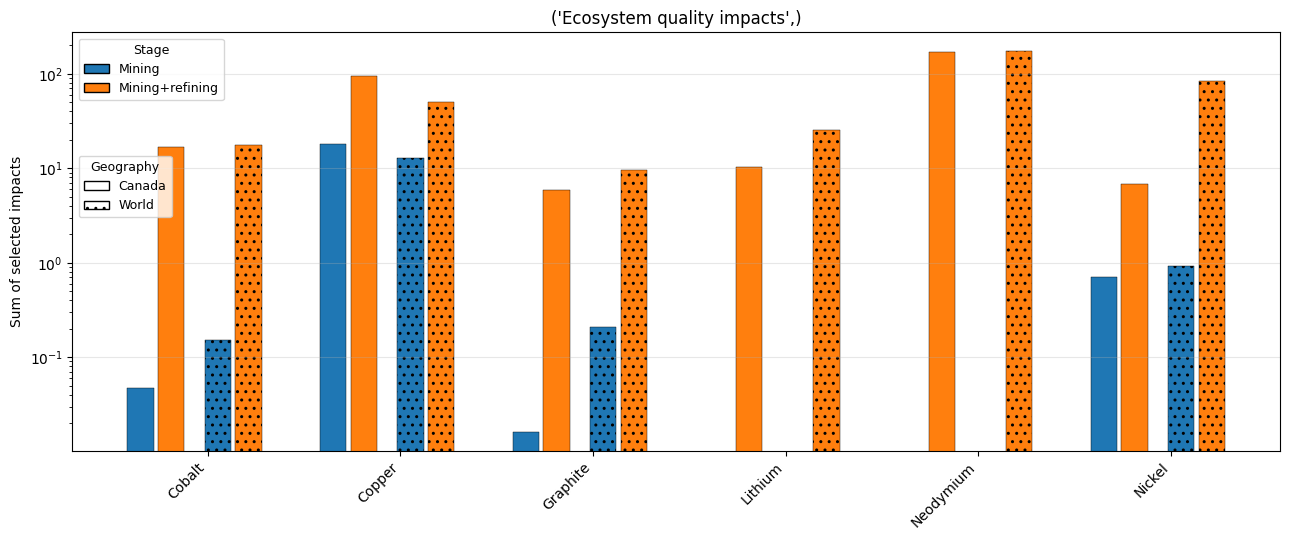

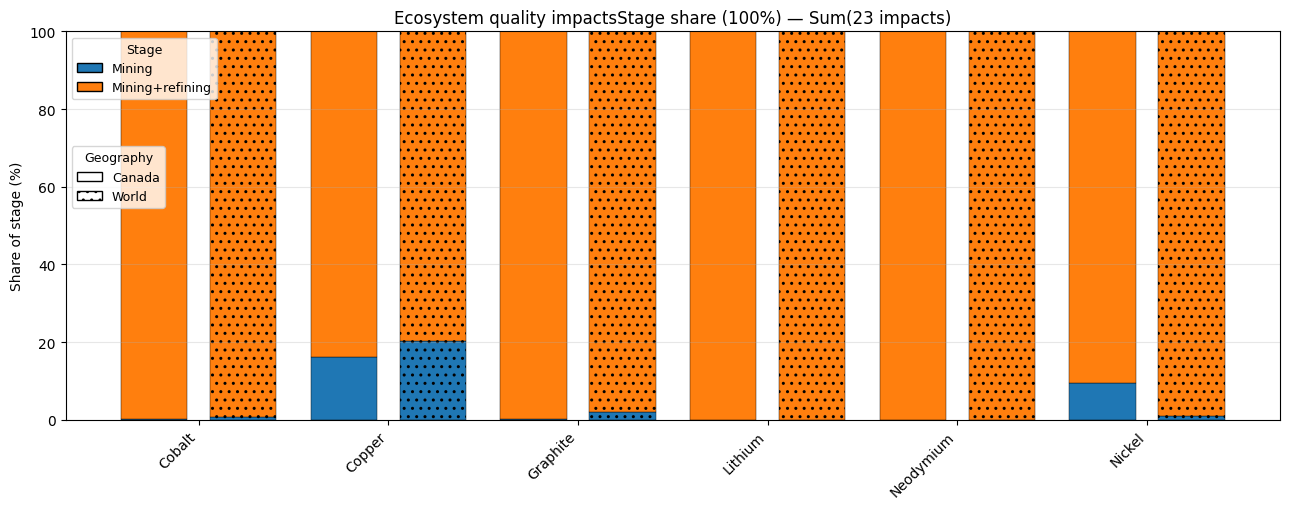

(<Figure size 1300x520 with 1 Axes>,
 Geography           Canada                                 World  \
 Reference point     Mining Mining+refining   Refining     Mining   
 Metal                                                              
 Cobalt            0.286129       99.713871  16.589827   0.843817   
 Copper           16.159103       83.840897  76.287305  20.430261   
 Graphite          0.271183       99.728817   5.936671   2.105040   
 Lithium           0.000000      100.000000   0.000000   0.000000   
 Neodymium         0.000000      100.000000   0.000000   0.000000   
 Nickel            9.494010       90.505990   6.081663   1.079347   
 
 Geography                                   
 Reference point Mining+refining   Refining  
 Metal                                       
 Cobalt                99.156183  17.562571  
 Copper                79.569739  37.526495  
 Graphite              97.894960   9.399899  
 Lithium              100.000000   0.000000  
 Neodymium        

In [132]:
plot_grouped_stage_bars_log(
    df_eq,
    impact_cols=impact_cols_eq,
    impact_mode="sum",
    scenario="IMAGE_SSP2L",
    year=2020,
    title_prefix="Ecosystem quality impacts",
    yscale="log",
    linthresh=1e-6,
    output_pdf="results/LCA/EQ_2020_log.pdf",
    output_png="results/LCA/EQ_2020_log.png",
)

# 2) Relatif (100%) – stacked en %
plot_percent_stacked_stage_bars(
    df_eq,
    impact_cols=impact_cols_eq,
    impact_mode="sum",
    scenario="IMAGE_SSP2L",
    year=2020,
    title_prefix="Ecosystem quality impacts",
    output_pdf="results/LCA/EQ_2020_pct.pdf",
    output_png="results/LCA/EQ_2020_pct.png",
)

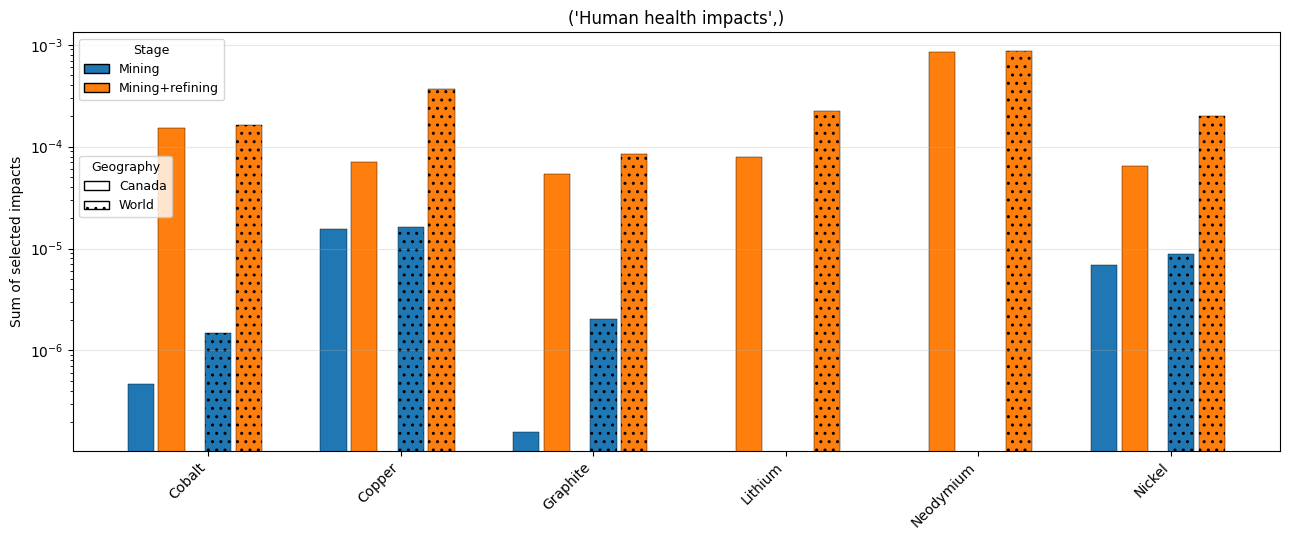

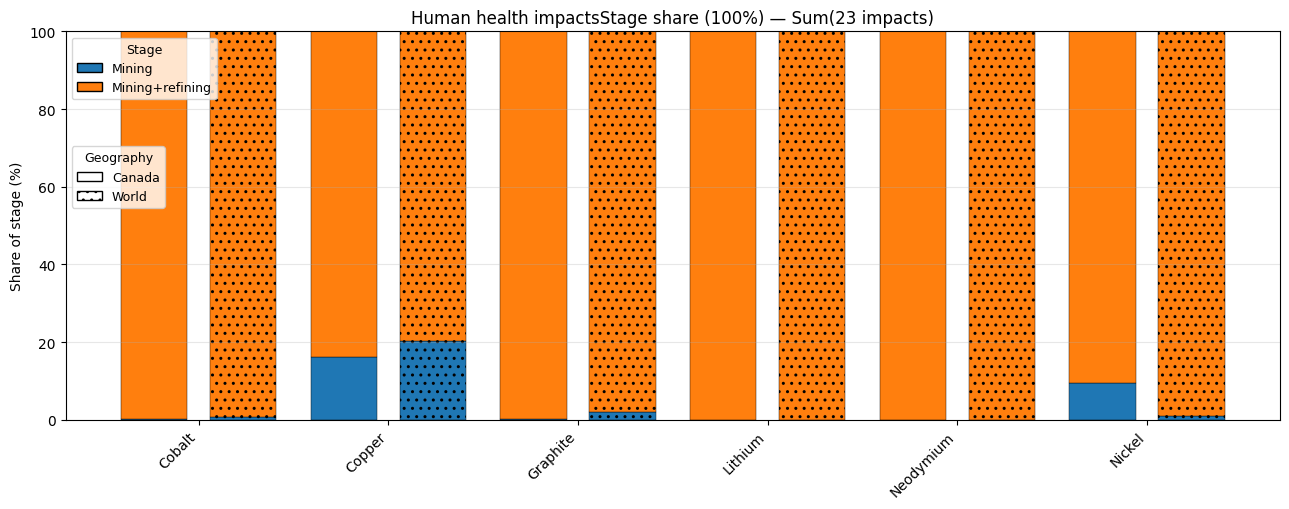

(<Figure size 1300x520 with 1 Axes>,
 Geography           Canada                                 World  \
 Reference point     Mining Mining+refining   Refining     Mining   
 Metal                                                              
 Cobalt            0.286129       99.713871  16.589827   0.843817   
 Copper           16.159103       83.840897  76.287305  20.430261   
 Graphite          0.271183       99.728817   5.936671   2.105040   
 Lithium           0.000000      100.000000   0.000000   0.000000   
 Neodymium         0.000000      100.000000   0.000000   0.000000   
 Nickel            9.494010       90.505990   6.081663   1.079347   
 
 Geography                                   
 Reference point Mining+refining   Refining  
 Metal                                       
 Cobalt                99.156183  17.562571  
 Copper                79.569739  37.526495  
 Graphite              97.894960   9.399899  
 Lithium              100.000000   0.000000  
 Neodymium        

In [133]:
plot_grouped_stage_bars_log(
    df_hh,
    impact_cols=impact_cols_hh,
    impact_mode="sum",
    scenario="IMAGE_SSP2L",
    year=2020,
    title_prefix="Human health impacts",
    yscale="log",
    linthresh=1e-6,
    output_pdf="results/LCA/HH_2020_log.pdf",
    output_png="results/LCA/HH_2020_log.png",
)

# 2) Relatif (100%) – stacked en %
plot_percent_stacked_stage_bars(
    df_eq,
    impact_cols=impact_cols_eq,
    impact_mode="sum",
    scenario="IMAGE_SSP2L",
    year=2020,
    title_prefix="Human health impacts",
    output_pdf="results/LCA/HH_2020_pct.pdf",
    output_png="results/LCA/HH_2020_pct.png",
)

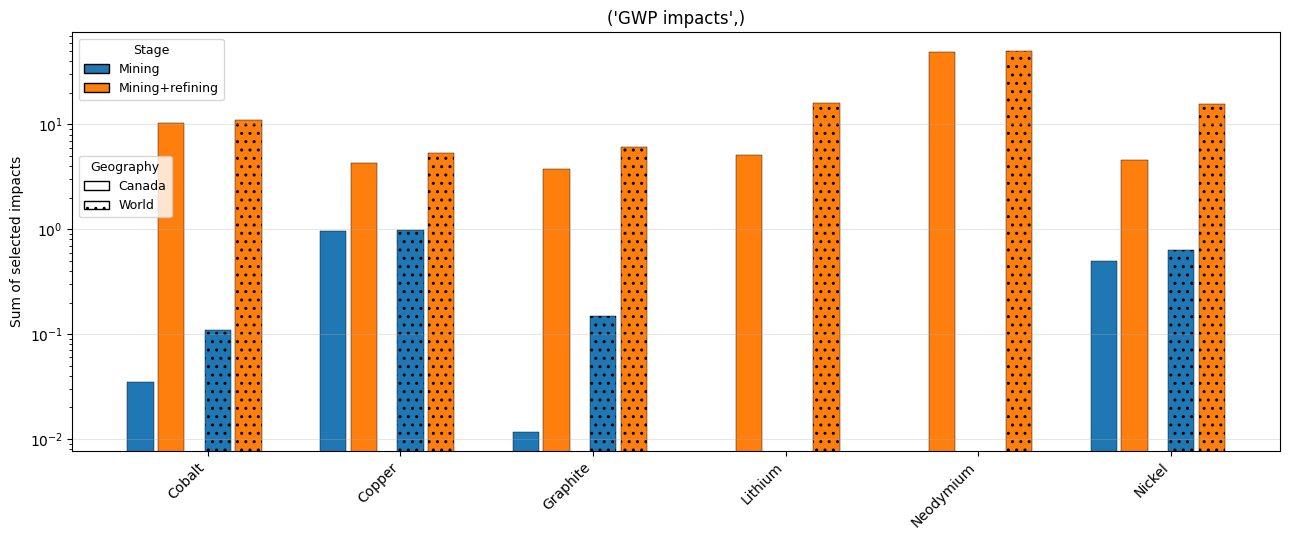

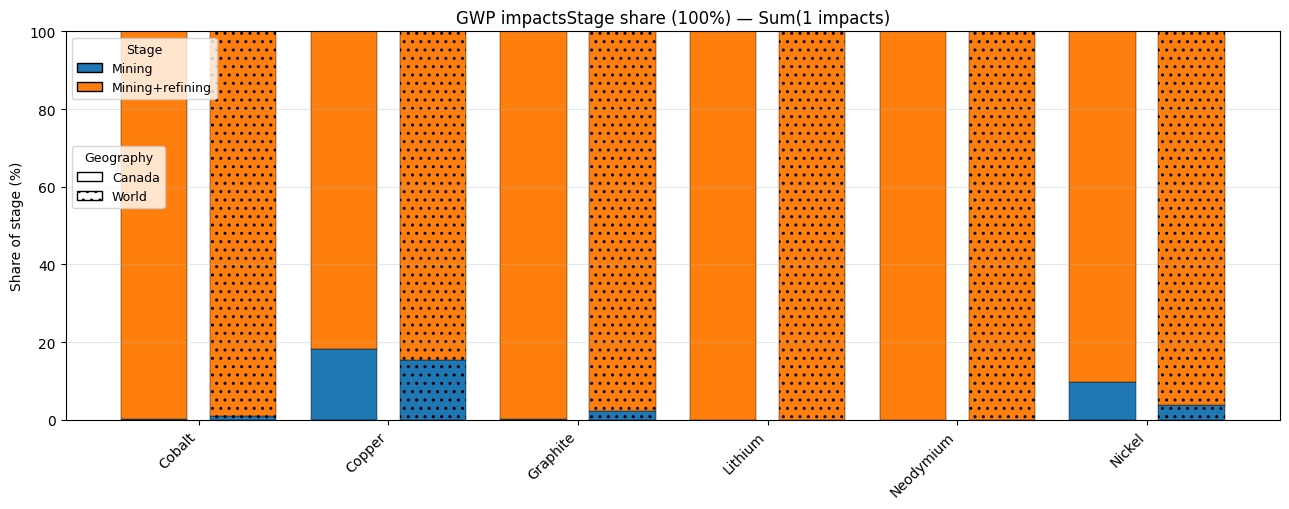

(<Figure size 1300x520 with 1 Axes>,
 Geography           Canada                                 World  \
 Reference point     Mining Mining+refining   Refining     Mining   
 Metal                                                              
 Cobalt            0.331746       99.668254  10.360392   0.968701   
 Copper           18.360533       81.639467   3.348828  15.416550   
 Graphite          0.312374       99.687626   3.713365   2.366913   
 Lithium           0.000000      100.000000   0.000000   0.000000   
 Neodymium         0.000000      100.000000   0.000000   0.000000   
 Nickel            9.721975       90.278025   4.113514   3.917881   
 
 Geography                                   
 Reference point Mining+refining   Refining  
 Metal                                       
 Cobalt                99.031299  11.014118  
 Copper                84.583450   4.411497  
 Graphite              97.633087   5.976248  
 Lithium              100.000000   0.000000  
 Neodymium        

In [134]:
# 1) Absolu (symlog) – grouped (Mining vs Refining côte à côte)
plot_grouped_stage_bars_log(
    df_gwp,
    impact_cols=impact_cols_gwp,
    impact_mode="sum",
    scenario="IMAGE_SSP2L",
    year=2020,
    title_prefix="GWP impacts",
    yscale="log",
    linthresh=1e-6,
    output_pdf="results/LCA/GWP_2020_log.pdf",
    output_png="results/LCA/GWP_2020_log.png",
)

# 2) Relatif (100%) – stacked en %
plot_percent_stacked_stage_bars(
    df_gwp,
    impact_cols=impact_cols_gwp,
    impact_mode="sum",
    scenario="IMAGE_SSP2L",
    year=2020,
    title_prefix="GWP impacts",
    output_pdf="results/LCA/GWP_2020_pct.pdf",
    output_png="results/LCA/GWP_2020_pct.png",
)

In [212]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def plot_mining_refining_scenarios_hatched(
    df,
    metal,
    impact_category,
    years=(2020, 2025, 2030, 2035, 2040),
    scenario_order=None,
    scenario_name_mapping=None,  # dict: raw -> pretty
    scenario_name_col="Scenario name",
    year_col="Year",
    metal_col="Metal",
    impact_col="Impact category",
    unit_col="Unit",
    mining_col="Mining",
    refining_col="Refining",
    title=None,
    figsize=(11, 5),
    output_path=None,
    dpi=300,
    mining_hatch="///",
    scenario_legend_ncol=4,     # nb de colonnes max pour la légende scénario
    legends_y1=-0.18,           # y ancre légende 1 (scenario)
    legends_y2=-0.40,           # y ancre légende 2 (stage)
    bottom_margin=0.38,         # marge basse pour éviter troncature
    tight_save=False,           # évite bbox_inches="tight" par défaut
):
    """
    Barplot groupé par année, scénarios côte à côte.
    Chaque barre = empilée Mining (hachuré) + Refining (plein), même couleur par scénario.

    df attendu: colonnes scenario_name_col, year_col, metal_col, impact_col, unit_col, mining_col, refining_col
    """

    d = df.copy()

    # Filtre
    d = d[(d[metal_col] == metal) & (d[impact_col] == impact_category)].copy()
    d[year_col] = pd.to_numeric(d[year_col], errors="coerce")
    d = d[d[year_col].isin(list(years))]

    if d.empty:
        raise ValueError(
            f"Aucune donnée pour metal={metal!r}, impact_category={impact_category!r}, years={years}"
        )

    # Mapping des noms de scénarios (optionnel)
    if scenario_name_mapping is not None:
        d[scenario_name_col] = d[scenario_name_col].replace(scenario_name_mapping)

    # Unité
    unit = ""
    if unit_col in d.columns:
        units = [u for u in d[unit_col].dropna().astype(str).unique() if u.strip()]
        unit = units[0] if units else ""

    # Ordre des scénarios
    if scenario_order is None:
        scenario_order = sorted(d[scenario_name_col].dropna().unique())
    else:
        # si scenario_order fourni, on garde seulement ceux présents
        present = set(d[scenario_name_col].dropna().unique())
        scenario_order = [s for s in scenario_order if s in present]

    if not scenario_order:
        raise ValueError("scenario_order vide (aucun scénario correspondant dans les données après mapping/filtre).")

    # Pivot Mining/Refining par (Year, Scenario)
    p = (
        d.pivot_table(
            index=year_col,
            columns=scenario_name_col,
            values=[mining_col, refining_col],
            aggfunc="first",
        )
        .reindex(index=list(years))
    )

    if (mining_col not in p.columns.get_level_values(0)) or (refining_col not in p.columns.get_level_values(0)):
        raise ValueError(
            f"Je ne trouve pas {mining_col!r}/{refining_col!r} après pivot. "
            f"Référence points dispo: {sorted(d.columns)}"
        )

    # Axes
    years_list = list(years)
    x = np.arange(len(years_list))

    n_s = len(scenario_order)
    group_width = 0.8
    bar_w = group_width / n_s

    fig, ax = plt.subplots(figsize=figsize)

    # Couleurs: cycle Matplotlib par défaut
    cycle_colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    if not cycle_colors:
        cycle_colors = [None] * n_s

    scenario_colors = {scen: cycle_colors[i % len(cycle_colors)] for i, scen in enumerate(scenario_order)}

    # Dessin des barres
    for i, scen in enumerate(scenario_order):
        if (mining_col, scen) not in p.columns or (refining_col, scen) not in p.columns:
            continue

        mining_vals = p[(mining_col, scen)].to_numpy(dtype=float)
        refining_vals = p[(refining_col, scen)].to_numpy(dtype=float)

        xpos = x - group_width / 2 + (i + 0.5) * bar_w
        col = scenario_colors[scen]

        # Mining (hachuré)
        ax.bar(
            xpos,
            mining_vals,
            width=bar_w,
            color=col,
            hatch=mining_hatch,
            linewidth=0.8,
        )

        # Refining (plein)
        ax.bar(
            xpos,
            refining_vals,
            width=bar_w,
            bottom=mining_vals,
            color=col,
            linewidth=0.8,
        )

    # Labels
    ax.set_xticks(x)
    ax.set_xticklabels([str(y) for y in years_list])
    ax.set_xlabel("")
    ax.set_ylabel(f"Impact ({unit})" if unit else "Impact")

    if title is None:
        title = f"{metal} — {impact_category}"
    ax.set_title(title)

    ax.margins(x=0.02)

    # --------- LÉGENDES CENTRÉES EN BAS (dans la largeur) ---------
    scenario_handles = [
        Patch(facecolor=scenario_colors[scen], edgecolor="black", label=scen)
        for scen in scenario_order
    ]

    leg1 = ax.legend(
        handles=scenario_handles,
        title="Scenario",
        loc="upper center",
        bbox_to_anchor=(0.5, legends_y1),
        ncol=min(len(scenario_order), scenario_legend_ncol),
        frameon=True,
        fontsize=9,
        title_fontsize=9,
    )
    ax.add_artist(leg1)

    style_handles = [
        Patch(facecolor="white", edgecolor="black", hatch=mining_hatch, label="Mining"),
        Patch(facecolor="white", edgecolor="black", label="Refining"),
    ]
    ax.legend(
        handles=style_handles,
        title="Stage",
        loc="upper center",
        bbox_to_anchor=(0.5, legends_y2),
        ncol=2,
        frameon=True,
        fontsize=9,
        title_fontsize=9,
    )

    # marge basse pour ne pas tronquer
    fig.subplots_adjust(bottom=bottom_margin)

    # Export
    if output_path:
        if tight_save:
            fig.savefig(output_path, dpi=dpi, bbox_inches="tight", pad_inches=0.05)
        else:
            fig.savefig(output_path, dpi=dpi)

    return fig, ax


In [222]:
df_scenarios

Reference point,Scenario name,Year,Metal,Impact category,Unit,Mining,Refining
0,100% World,2020,Cobalt,Climate change ST (kg CO2 eq (short)),,1.088018e-01,11.014118
1,100% World,2020,Cobalt,Total EQ (PDF.m2.yr),PDF.m2.yr,7.536993e-02,8.781285
2,100% World,2020,Cobalt,Total HH (DALY),DALY,7.466835e-07,0.000081
3,100% World,2020,Copper,Climate change ST (kg CO2 eq (short)),,9.832747e-01,4.411497
4,100% World,2020,Copper,Total EQ (PDF.m2.yr),PDF.m2.yr,6.481931e+00,18.763247
...,...,...,...,...,...,...,...
235,100% CA,2040,Graphite,Total EQ (PDF.m2.yr),PDF.m2.yr,8.093529e-03,2.968335
236,100% CA,2040,Graphite,Total HH (DALY),DALY,7.931155e-08,0.000027
237,100% CA,2040,Nickel,Climate change ST (kg CO2 eq (short)),,4.567210e-01,3.452342
238,100% CA,2040,Nickel,Total EQ (PDF.m2.yr),PDF.m2.yr,3.563632e-01,3.040832


In [214]:
scenario_name_mapping = {
    'IMAGE_SSP2L | S1 World-World': '100% World',
    'IMAGE_SSP2L | S2 CA-World': 'Mining CA, refining World',
    'IMAGE_SSP2L | S3 World-CA': 'Mining World, refining CA',
    'IMAGE_SSP2L | S4 CA-CA': '100% CA'
}

In [215]:
df_scenarios["Scenario name"] = (
    df_scenarios["Scenario name"]
    .replace(scenario_name_mapping)
)

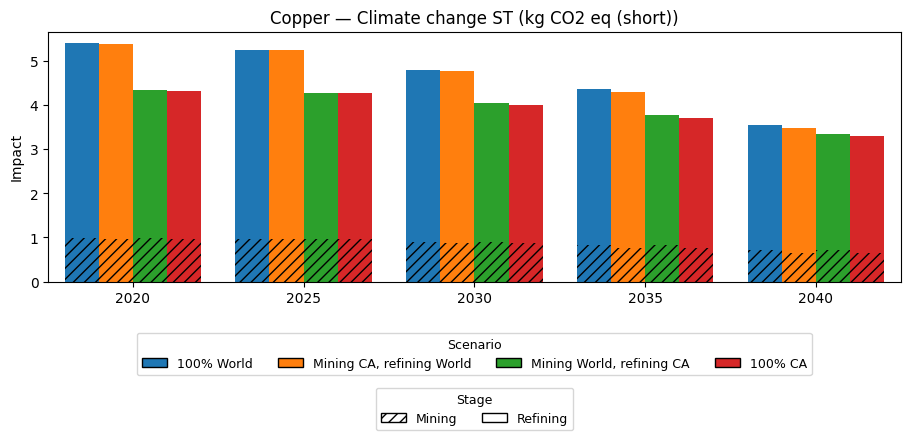

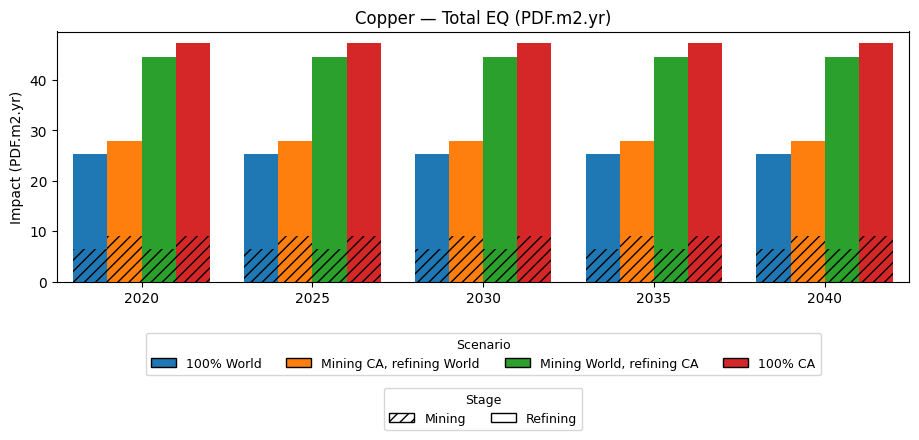

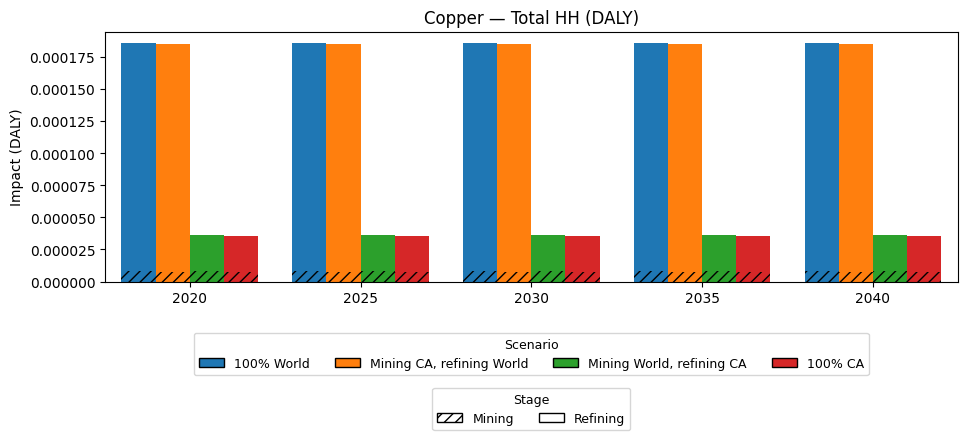

In [223]:
fig, ax = plot_mining_refining_scenarios_hatched(
    df_scenarios,
    metal="Copper",
    impact_category="Climate change ST (kg CO2 eq (short))",
    years=(2020, 2025, 2030, 2035, 2040),
    scenario_order=[
        "100% World",
        "Mining CA, refining World",
        "Mining World, refining CA",
        "100% CA",
    ],
    output_path='results/LCA/plots/copper_scenarios_gwp'
)
plt.show()

fig, ax = plot_mining_refining_scenarios_hatched(
    df_scenarios,
    metal="Copper",
    impact_category="Total EQ (PDF.m2.yr)",
    years=(2020, 2025, 2030, 2035, 2040),
    scenario_order=[
        "100% World",
        "Mining CA, refining World",
        "Mining World, refining CA",
        "100% CA",
    ],
    output_path='results/LCA/plots/copper_scenarios_eq'
)
plt.show()

fig, ax = plot_mining_refining_scenarios_hatched(
    df_scenarios,
    metal="Copper",
    impact_category="Total HH (DALY)",
    years=(2020, 2025, 2030, 2035, 2040),
    scenario_order=[
        "100% World",
        "Mining CA, refining World",
        "Mining World, refining CA",
        "100% CA",
    ],
    output_path='results/LCA/plots/copper_scenarios_hh'
)
plt.show()

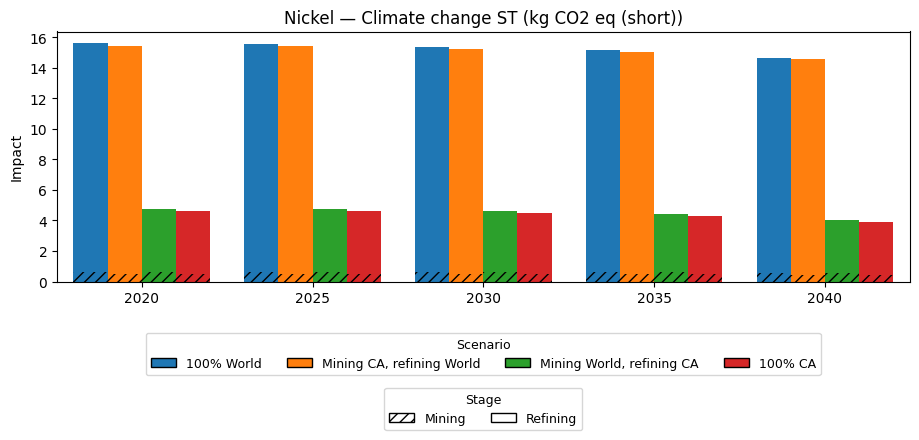

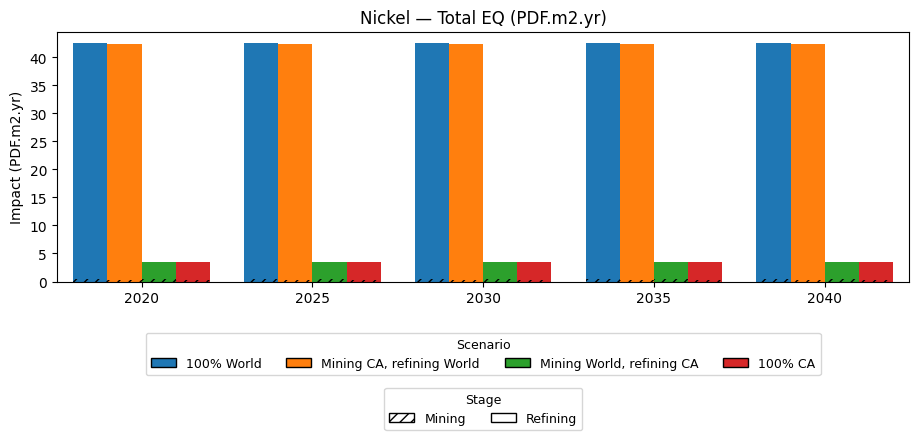

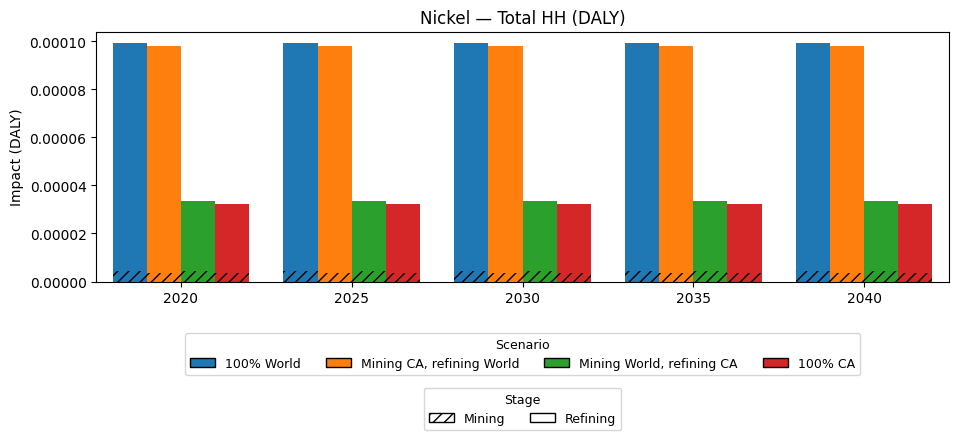

In [224]:
fig, ax = plot_mining_refining_scenarios_hatched(
    df_scenarios,
    metal="Nickel",
    impact_category="Climate change ST (kg CO2 eq (short))",
    years=(2020, 2025, 2030, 2035, 2040),
    scenario_order=[
        "100% World",
        "Mining CA, refining World",
        "Mining World, refining CA",
        "100% CA",
    ],
    output_path='results/LCA/plots/nickel_scenarios_gwp'
)
plt.show()

fig, ax = plot_mining_refining_scenarios_hatched(
    df_scenarios,
    metal="Nickel",
    impact_category="Total EQ (PDF.m2.yr)",
    years=(2020, 2025, 2030, 2035, 2040),
    scenario_order=[
        "100% World",
        "Mining CA, refining World",
        "Mining World, refining CA",
        "100% CA",
    ],
    output_path='results/LCA/plots/nickel_scenarios_eq'
)
plt.show()

fig, ax = plot_mining_refining_scenarios_hatched(
    df_scenarios,
    metal="Nickel",
    impact_category="Total HH (DALY)",
    years=(2020, 2025, 2030, 2035, 2040),
    scenario_order=[
        "100% World",
        "Mining CA, refining World",
        "Mining World, refining CA",
        "100% CA",
    ],
    output_path='results/LCA/plots/nickel_scenarios_hh'
)
plt.show()

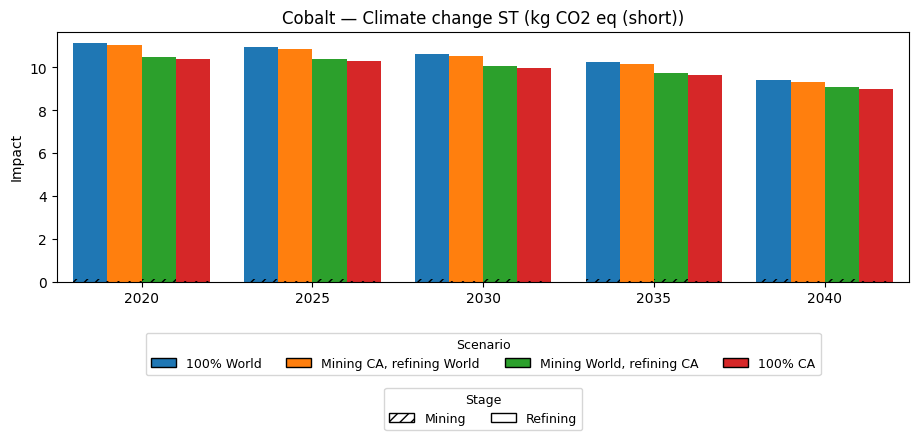

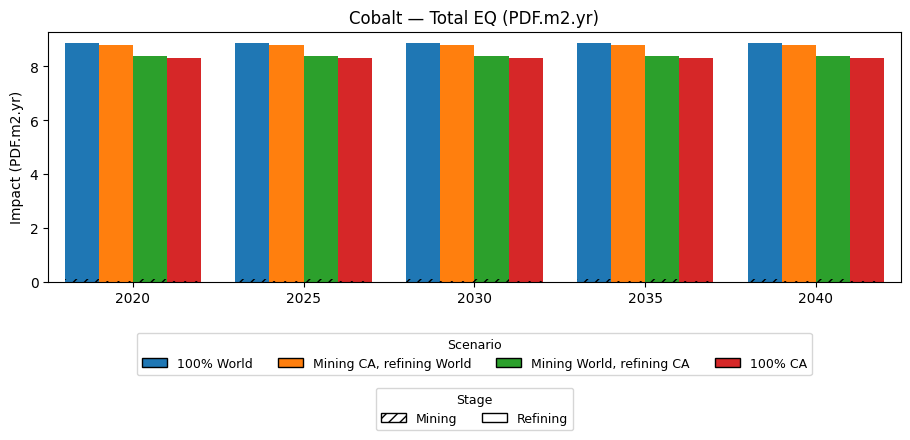

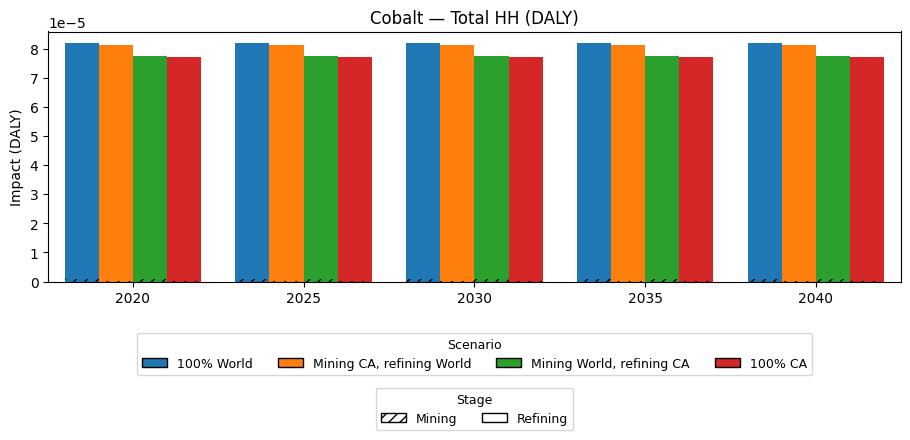

In [225]:
fig, ax = plot_mining_refining_scenarios_hatched(
    df_scenarios,
    metal="Cobalt",
    impact_category="Climate change ST (kg CO2 eq (short))",
    years=(2020, 2025, 2030, 2035, 2040),
    scenario_order=[
        "100% World",
        "Mining CA, refining World",
        "Mining World, refining CA",
        "100% CA",
    ],
    output_path='results/LCA/plots/cobalt_scenarios_gwp'
)
plt.show()

fig, ax = plot_mining_refining_scenarios_hatched(
    df_scenarios,
    metal="Cobalt",
    impact_category="Total EQ (PDF.m2.yr)",
    years=(2020, 2025, 2030, 2035, 2040),
    scenario_order=[
        "100% World",
        "Mining CA, refining World",
        "Mining World, refining CA",
        "100% CA",
    ],
    output_path='results/LCA/plots/cobalt_scenarios_eq'
)
plt.show()

fig, ax = plot_mining_refining_scenarios_hatched(
    df_scenarios,
    metal="Cobalt",
    impact_category="Total HH (DALY)",
    years=(2020, 2025, 2030, 2035, 2040),
    scenario_order=[
        "100% World",
        "Mining CA, refining World",
        "Mining World, refining CA",
        "100% CA",
    ],
    output_path='results/LCA/plots/cobalt_scenarios_hh'
)
plt.show()

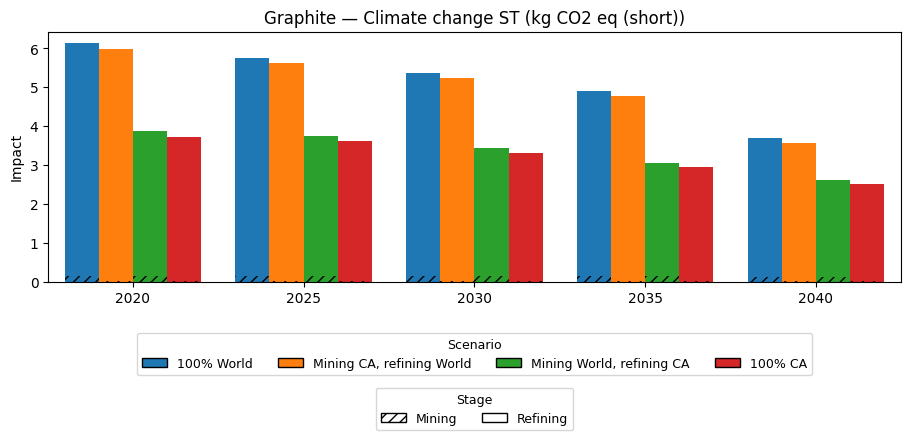

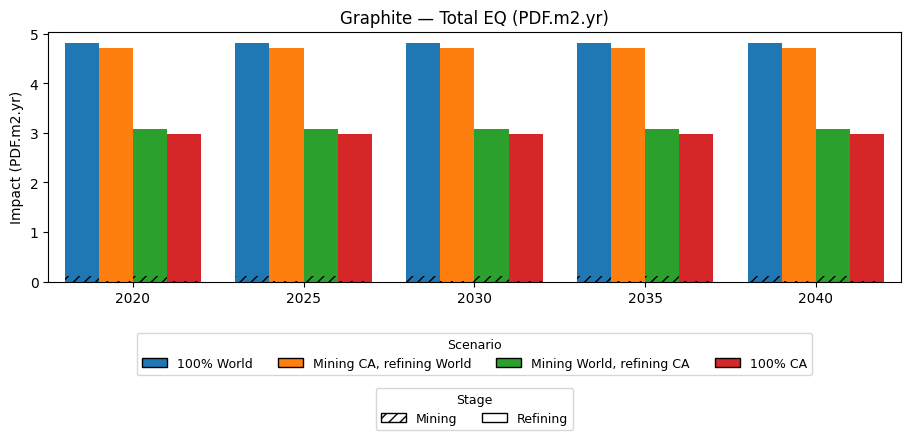

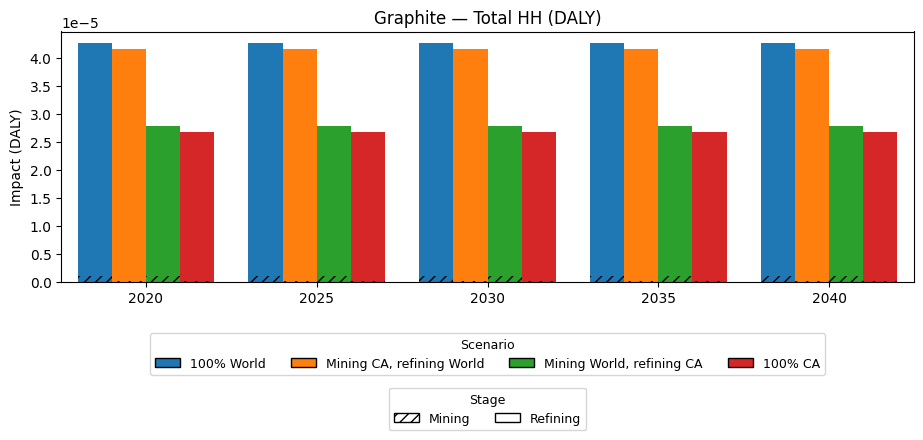

In [226]:
fig, ax = plot_mining_refining_scenarios_hatched(
    df_scenarios,
    metal="Graphite",
    impact_category="Climate change ST (kg CO2 eq (short))",
    years=(2020, 2025, 2030, 2035, 2040),
    scenario_order=[
        "100% World",
        "Mining CA, refining World",
        "Mining World, refining CA",
        "100% CA",
    ],
    output_path='results/LCA/plots/graphite_scenarios_gwp'
)
plt.show()

fig, ax = plot_mining_refining_scenarios_hatched(
    df_scenarios,
    metal="Graphite",
    impact_category="Total EQ (PDF.m2.yr)",
    years=(2020, 2025, 2030, 2035, 2040),
    scenario_order=[
        "100% World",
        "Mining CA, refining World",
        "Mining World, refining CA",
        "100% CA",
    ],
    output_path='results/LCA/plots/graphite_scenarios_eq'
)
plt.show()

fig, ax = plot_mining_refining_scenarios_hatched(
    df_scenarios,
    metal="Graphite",
    impact_category="Total HH (DALY)",
    years=(2020, 2025, 2030, 2035, 2040),
    scenario_order=[
        "100% World",
        "Mining CA, refining World",
        "Mining World, refining CA",
        "100% CA",
    ],
    output_path='results/LCA/plots/graphite_scenarios_hh'
)
plt.show()

# Midpoint contributions

In [220]:
INVENTORIES_2020_L_ds

{'Cu mining CA': 'copper mine operation and beneficiation, sulfide ore' (kilogram, CA, None),
 'Ni mining CA': 'nickel mine operation and benefication to nickel concentrate, 16% Ni' (kilogram, CA-QC, None),
 'Co mining CA': 'copper-cobalt mining, industrial, economic allocation' (kilogram, CA, None),
 'C mining CA': 'graphite ore mining' (kilogram, CA, None),
 'Cu mining World': 'market for copper concentrate, sulfide ore' (kilogram, World, None),
 'Ni mining World': 'market for nickel concentrate, 16% Ni' (kilogram, World, None),
 'Co mining World': 'market for copper-cobalt ore' (kilogram, World, None),
 'C mining World': 'market for graphite ore, mined' (kilogram, World, None),
 'Cu refining CA': 'copper production, cathode, solvent extraction and electrowinning process' (kilogram, CA, None),
 'Ni refining CA': 'processing of nickel-rich materials' (kilogram, CA, None),
 'Li refining CA': 'lithium carbonate production, from spodumene' (kilogram, CA, None),
 'Co refining CA': 'cobalt

In [221]:
df_hh_mp_contributions, df_eq_mp_contributions = compute_midpoint_contributions(
    INVENTORIES_2020_L_ds,
    damage_version="IMPACT World+ Damage 2.1 for ecoinvent v3.10"
)

In [13]:
df_hh_mp_contributions

,Commodity,"Climate change, human health, long term","Climate change, human health, short term","Human toxicity cancer, long term","Human toxicity cancer, short term","Human toxicity non-cancer, long term","Human toxicity non-cancer, short term","Ionizing radiations, human health",Ozone layer depletion,Particulate matter formation,"Photochemical ozone formation, human health","Water availability, human health"
0,Cu mining CA,0.625445,0.197150,0.002045,0.068759,0.065396,0.041066,0.000098,2.120749e-06,0.000020,1.166925e-06,0.000018
1,Ni mining CA,0.734337,0.226613,0.000612,0.010922,0.018529,0.008938,0.000019,2.170388e-06,0.000020,1.134199e-06,0.000007
2,Co mining CA,0.755172,0.228762,0.000161,0.010119,0.004028,0.001736,0.000006,3.397278e-06,0.000007,1.490292e-06,0.000003
3,C mining CA,0.750051,0.230093,0.000238,0.010436,0.006526,0.002597,0.000035,3.019778e-06,0.000012,1.359214e-06,0.000008
4,Cu mining World,0.606950,0.189729,0.001828,0.103336,0.061452,0.036138,0.000269,2.431299e-06,0.000116,1.210649e-06,0.000179
5,Ni mining World,0.728797,0.224003,0.000909,0.011681,0.024910,0.009369,0.000144,2.557660e-06,0.000077,1.317871e-06,0.000106
6,Co mining World,0.751398,0.227342,0.000547,0.011263,0.007319,0.002115,0.000006,3.243925e-06,0.000004,1.430555e-06,0.000002
7,C mining World,0.749705,0.227223,0.000660,0.011398,0.008663,0.002334,0.000008,3.110565e-06,0.000003,1.371987e-06,0.000002
8,Cu refining CA,0.597641,0.188991,0.002819,0.054131,0.096760,0.059548,0.000063,1.903677e-06,0.000023,1.101838e-06,0.000021
9,Ni refining CA,0.725944,0.222708,0.000970,0.012719,0.027094,0.010190,0.000172,2.595439e-06,0.000082,1.312223e-06,0.000118


In [14]:
df_eq_mp_contributions

,Commodity,"Climate change, ecosystem quality, long term","Climate change, ecosystem quality, short term",Fisheries impact,Freshwater acidification,"Freshwater ecotoxicity, long term","Freshwater ecotoxicity, short term",Freshwater eutrophication,"Ionizing radiations, ecosystem quality","Land occupation, biodiversity",...,"Marine ecotoxicity, long term","Marine ecotoxicity, short term",Marine eutrophication,"Photochemical ozone formation, ecosystem quality",Terrestrial acidification,"Terrestrial ecotoxicity, long term","Terrestrial ecotoxicity, short term",Thermally polluted water,"Water availability, freshwater ecosystem","Water availability, terrestrial ecosystem"
0,Cu mining CA,0.039279,0.012381,6.064267e-15,1.550907e-07,0.897766,0.003621,7.877516e-09,7.102933e-12,3.808092e-07,...,7.833176e-08,7.777694e-07,0.000399,0.000015,0.000001,0.002859,0.028389,7.710630e-10,1.261204e-10,1.185575e-09
1,Ni mining CA,0.526067,0.162342,5.173278e-14,4.169747e-06,0.071090,0.024451,2.055228e-08,1.192602e-11,3.495362e-06,...,6.423361e-08,8.729949e-08,0.002623,0.000161,0.000028,0.002345,0.003186,6.836130e-09,5.407525e-10,4.219622e-08
2,Co mining CA,0.552201,0.167277,3.017844e-15,6.489229e-07,0.028617,0.027894,1.110377e-08,3.440057e-12,1.583448e-06,...,1.721216e-08,2.124469e-08,0.000100,0.000226,0.000004,0.000628,0.000775,9.223028e-09,2.490600e-10,7.149299e-09
3,C mining CA,0.545377,0.167306,1.115162e-14,1.131689e-06,0.038238,0.028786,1.687403e-08,3.163973e-11,1.990052e-06,...,3.477088e-08,5.946048e-08,0.000146,0.000204,0.000007,0.001269,0.002170,8.218986e-09,6.167932e-10,7.926193e-09
4,Cu mining World,0.056222,0.017575,6.167404e-15,1.189203e-06,0.879810,0.004457,2.453286e-07,3.241733e-11,2.102219e-06,...,5.880786e-08,4.753916e-07,0.000445,0.000022,0.000008,0.002147,0.017352,1.758526e-08,1.829402e-09,6.644912e-09
5,Ni mining World,0.519450,0.159658,4.408541e-14,8.019731e-06,0.080973,0.025431,1.116508e-06,1.374450e-10,1.123533e-05,...,8.480149e-08,1.022891e-07,0.002135,0.000183,0.000054,0.003096,0.003734,8.365977e-08,8.329255e-09,5.964262e-08
6,Co mining World,0.552352,0.167119,7.558292e-15,3.303338e-07,0.028634,0.026841,6.976916e-09,3.451525e-12,1.051972e-06,...,3.042966e-08,5.240034e-08,0.000097,0.000218,0.000002,0.001111,0.001913,4.681849e-09,1.493553e-10,7.436695e-09
7,C mining World,0.549604,0.166575,9.337770e-15,2.722834e-07,0.031842,0.027887,6.177675e-09,4.601679e-12,9.241363e-07,...,3.557395e-08,6.352988e-08,0.000098,0.000209,0.000002,0.001299,0.002319,3.229636e-09,1.473162e-10,7.420106e-09
8,Cu refining CA,0.033493,0.010591,6.583042e-15,1.628938e-07,0.924186,0.002817,7.522458e-09,3.835173e-12,3.497165e-07,...,3.949322e-08,3.961449e-07,0.000027,0.000013,0.000001,0.001442,0.014459,8.535701e-10,1.270281e-10,1.125710e-09
9,Ni refining CA,0.514258,0.157766,4.402402e-14,8.198939e-06,0.086788,0.026310,1.244877e-06,1.638913e-10,1.219340e-05,...,1.097160e-07,1.444965e-07,0.001976,0.000181,0.000055,0.004005,0.005274,9.212542e-08,9.238422e-09,5.964474e-08


In [16]:
with pd.ExcelWriter(r'results/LCA/midpoint_contributions_2020_L.xlsx') as writer:
    df_hh_mp_contributions.to_excel(writer, sheet_name='HH', index=False)
    df_eq_mp_contributions.to_excel(writer, sheet_name='EQ', index=False)

Plot saved to results/LCA/hh_midpoint_contributions_2020_L.png


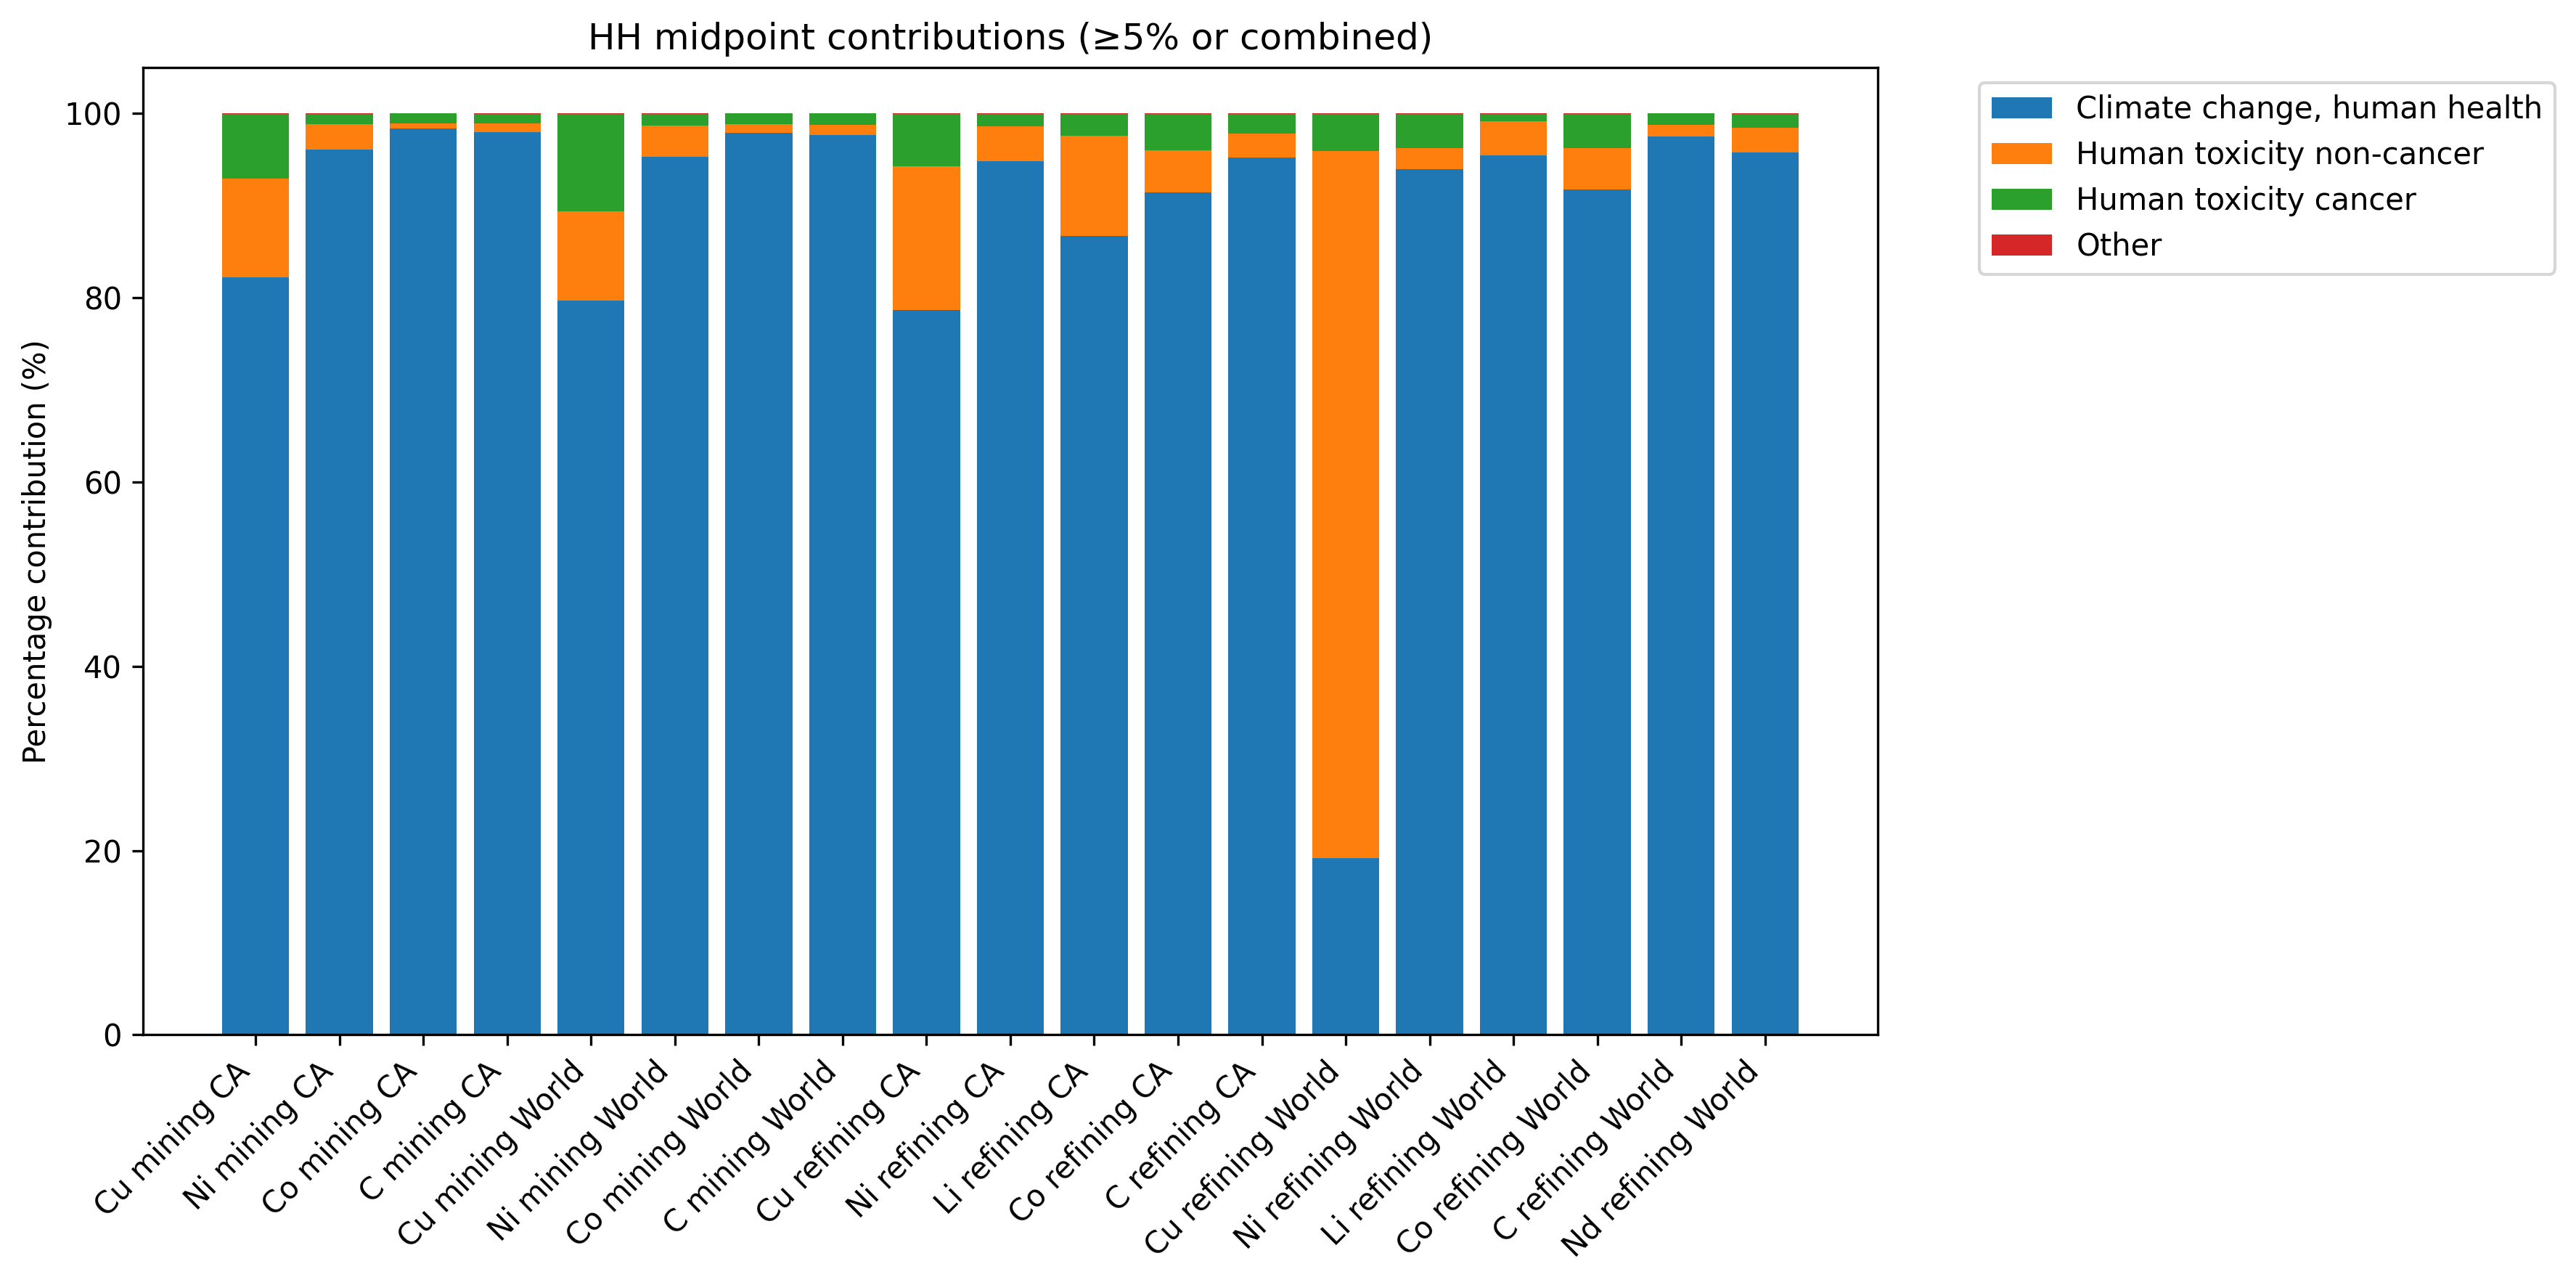

In [31]:
plot_midpoint_contributions(df_hh_mp_contributions, category='HH', threshold=0.05, combine_terms=True, save_path=r'results/LCA/hh_midpoint_contributions_2020_L.png')

Plot saved to results/LCA/eq_midpoint_contributions_2020_L.png


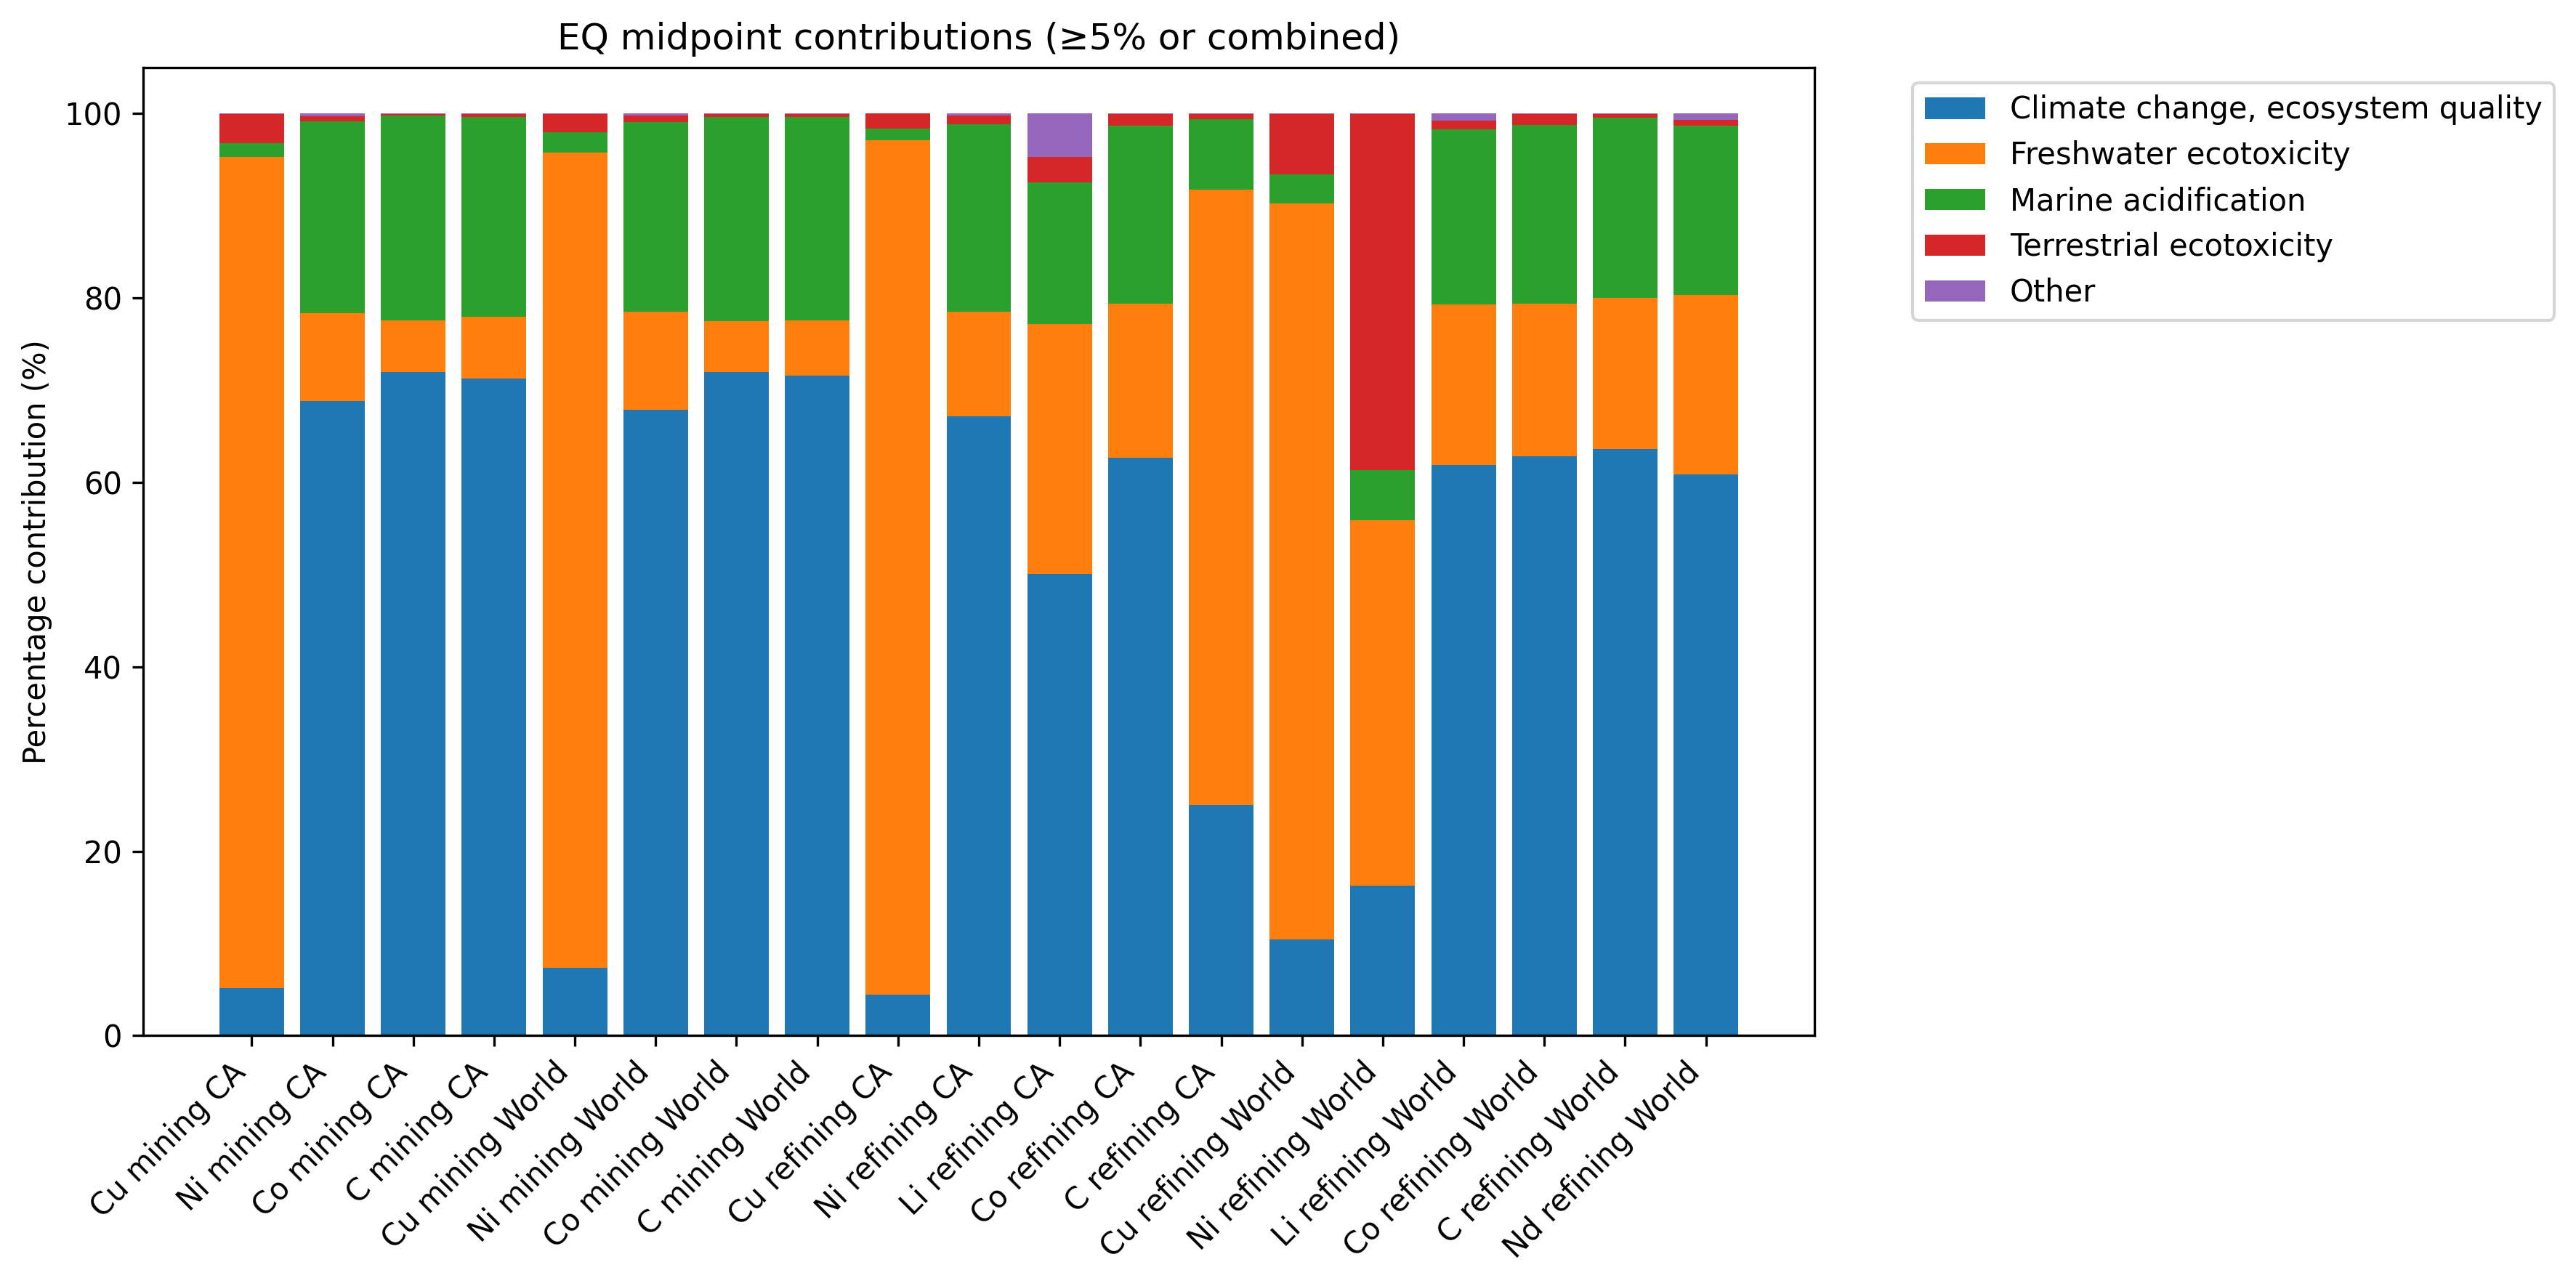

In [32]:
plot_midpoint_contributions(df_eq_mp_contributions, category='EQ', threshold=0.05, combine_terms=True, save_path=r'results/LCA/eq_midpoint_contributions_2020_L.png')

# Contribution analysis

In [18]:
ca_ei_eq = direct_bio_and_first_tier_tech(
    INVENTORIES_2020_L_ds,
    method_id=TOTAL_EQ
)

In [20]:
ca_ei_hh = direct_bio_and_first_tier_tech(
    INVENTORIES_2020_L_ds,
    method_id=TOTAL_HH
)

In [24]:
ca_ei_gwp = direct_bio_and_first_tier_tech(
    INVENTORIES_2020_L_ds,
    method_id=GWP_100
)

In [25]:
with pd.ExcelWriter(r'results/LCA/contribution_analysis_2020_L.xlsx') as writer:
    ca_ei_eq.to_excel(writer, sheet_name='HH', index=False)
    ca_ei_hh.to_excel(writer, sheet_name='EQ', index=False)
    ca_ei_gwp.to_excel(writer, sheet_name='GWP_100', index=False)

In [36]:
import numpy as np
def plot_stacked_contribution_by_activity(
    df,
    impact_col="share_%",
    commodity_col="reference_product_market",
    name_col="name",
    flow_type_col="flow_type",
    commodity_order=None,
    act_to_hex=None,                     # dict: {activity_name: "#RRGGBB"}
    act_to_plot=None,                    # list of activities to display (order preserved)
    top_n=12,                            # used only if act_to_plot=None
    others_label="Others",
    hatch_technosphere="///",
    hatch_biosphere=None,
    bar_spacing=0.15,
    figsize=(11, 7),
    xlabel=None,
    title=None,
    normalize_to_percent=False,          # if True: each commodity is normalized to 100%
    legend=True,
    legend_fontsize=9,
    legend_ncol=1,
    output_path=None,
    dpi=600,
    # --- NEW ---
    direct_first=True,                   # force all Direct (biosphere) to the left
    legend_direct_first=True,            # force Direct entries first in legend
    direct_label="",
    indirect_label=" ",
):
    """
    Horizontal stacked contribution barplot across ALL commodities.

    - Colors encode activity (name)
    - Hatch encodes flow_type (Technosphere hatched; Biosphere solid)
    - Unselected activities grouped into 'Others'
    - Legend style: "Activity — Direct" and "Activity — Indirect"

    NEW:
    - direct_first=True: draw ALL Direct segments first (thus leftmost), then Indirect.
    - legend_direct_first=True: reorder legend so Direct entries appear first.

    Required columns in df:
      - commodity_col
      - name_col
      - flow_type_col (expects e.g. 'Technosphere (first-tier)' and 'Biosphere (direct)')
      - impact_col
    """
    df = df.copy()

    # --- Basic checks
    for c in [commodity_col, name_col, flow_type_col, impact_col]:
        if c not in df.columns:
            raise ValueError(f"Missing column: '{c}'")

    # Coerce impacts to numeric
    df[impact_col] = pd.to_numeric(df[impact_col], errors="coerce").fillna(0.0)

    # --- Decide which activities to plot
    if act_to_plot is None:
        tmp = (
            df.groupby(name_col, as_index=False)[impact_col].sum()
            .assign(_abs=lambda x: x[impact_col].abs())
            .sort_values("_abs", ascending=False)
        )
        act_to_plot = tmp[name_col].head(top_n).tolist()
    act_to_plot = list(act_to_plot)  # preserve given order

    # --- Colors
    act_to_hex = act_to_hex or {}

    def _get_color(act, i):
        if act in act_to_hex:
            return act_to_hex[act]
        cmap = plt.get_cmap("tab20")
        return cmap(i % 20)

    # --- Group non-selected -> Others
    df["_act"] = df[name_col].where(df[name_col].isin(act_to_plot), others_label)

    # --- Aggregate
    agg = (
        df.groupby([commodity_col, "_act", flow_type_col], as_index=False)[impact_col]
        .sum()
        .rename(columns={impact_col: "impact"})
    )

    # --- Commodity order
    if commodity_order is not None:
        missing = set(commodity_order) - set(agg[commodity_col].unique())
        if missing:
            raise ValueError(f"Commodities not found in data: {missing}")
    else:
        commodity_order = (
            agg.groupby(commodity_col, as_index=False)["impact"].sum()
            .assign(_abs=lambda x: x["impact"].abs())
            .sort_values("_abs", ascending=False)[commodity_col]
            .tolist()
        )

    # --- Fixed bar heights
    heights = np.full(len(commodity_order), 0.7, dtype=float)

    # y positions with spacing
    y_pos = np.zeros(len(commodity_order), dtype=float)
    for i in range(1, len(commodity_order)):
        y_pos[i] = y_pos[i - 1] + heights[i - 1] + bar_spacing

    # --- Flow labels (expected)
    flow_bio = "Biosphere (direct)"
    flow_tech = "Technosphere (first-tier)"

    # --- Flow order: bio first, then tech, then any others
    flow_types_present = set(agg[flow_type_col].unique().tolist())
    flow_order = []
    if flow_bio in flow_types_present:
        flow_order.append(flow_bio)
    if flow_tech in flow_types_present:
        flow_order.append(flow_tech)
    flow_order += [ft for ft in sorted(flow_types_present) if ft not in set(flow_order)]

    # --- Activity order
    acts_present = set(agg["_act"].unique().tolist())
    act_order = [a for a in act_to_plot if a in acts_present]
    if others_label in acts_present:
        act_order.append(others_label)

    # --- Pivot
    pivot = (
        agg.pivot_table(
            index=[commodity_col],
            columns=["_act", flow_type_col],
            values="impact",
            aggfunc="sum",
            fill_value=0.0,
        )
        .reindex(index=commodity_order, fill_value=0.0)
    )

    # Normalize each commodity to 100% if requested
    if normalize_to_percent:
        row_sums = pivot.sum(axis=1).replace(0, np.nan)
        pivot = (pivot.div(row_sums, axis=0) * 100.0).fillna(0.0)
        if xlabel is None:
            xlabel = "Contribution (%)"
    else:
        if xlabel is None:
            xlabel = impact_col

    # --- Plot
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    left = np.zeros(len(commodity_order), dtype=float)

    labeled = set()

    def _direct_or_indirect(ft: str) -> str:
        # Map known flow types to Direct/Indirect; fallback: treat as Indirect
        if ft == flow_bio:
            return direct_label
        if ft == flow_tech:
            return indirect_label
        return indirect_label

    def _hatch_for(ft: str):
        if ft == flow_tech:
            return hatch_technosphere
        if ft == flow_bio:
            return hatch_biosphere
        # unknown: treat like indirect hatch (safer visual cue)
        return hatch_technosphere

    # --- Drawing order:
    # If direct_first: draw ALL flows in flow_order outer loop (Direct first), so Direct is leftmost.
    # Else: draw by activity first, then flow (original behavior).
    if direct_first:
        outer = [("flow", ft) for ft in flow_order]
        inner_kind = "act"
    else:
        outer = [("act", act) for act in act_order]
        inner_kind = "flow"

    def _iter_pairs():
        if direct_first:
            for ft in flow_order:
                for i_act, act in enumerate(act_order):
                    yield act, i_act, ft
        else:
            for i_act, act in enumerate(act_order):
                for ft in flow_order:
                    yield act, i_act, ft

    for act, i_act, ft in _iter_pairs():
        color = _get_color(act, i_act)

        try:
            vals = pivot[(act, ft)].values
        except KeyError:
            vals = np.zeros(len(commodity_order), dtype=float)

        if np.allclose(vals, 0):
            continue

        hatch = _hatch_for(ft)

        suffix = _direct_or_indirect(ft)
        label_full = f"{act} {suffix}"
        label = label_full if label_full not in labeled else "_nolegend_"
        if label != "_nolegend_":
            labeled.add(label_full)

        ax.barh(
            y_pos,
            vals,
            left=left,
            height=heights,
            color=color,
            hatch=hatch,
            edgecolor="black",
            linewidth=0.5,
            label=label,
        )
        left += vals

    # Axes
    ax.set_yticks(y_pos)
    ax.set_yticklabels(commodity_order)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel, fontsize=12)
    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=11)

    if title is not None:
        ax.set_title(title, fontsize=12)

    # --- Legend: force Direct entries first (then Indirect)
    if legend:
        handles, labels = ax.get_legend_handles_labels()
        pairs = [(h, l) for h, l in zip(handles, labels) if l and l != "_nolegend_"]

        if legend_direct_first:
            def _is_direct(lbl: str) -> bool:
                return f"— {direct_label}" in lbl

            # Direct first; stable sort keeps within-group order
            pairs = sorted(pairs, key=lambda hl: (0 if _is_direct(hl[1]) else 1))

        handles_sorted = [h for h, _ in pairs]
        labels_sorted = [l for _, l in pairs]

        ax.legend(
            handles_sorted,
            labels_sorted,
            loc="upper left",
            bbox_to_anchor=(1.01, 1.0),
            frameon=False,
            fontsize=legend_fontsize,
            ncol=legend_ncol,
        )

    # Save
    if output_path:
        fig.savefig(output_path, dpi=dpi, bbox_inches="tight", facecolor="white")

    plt.show()
    return fig, ax

In [37]:
ca_ei_gwp

,lci_name,activity_name,flow_type,name,reference_product,categories,unit,location,impact_score,share_%,total_score
0,C mining CA,graphite ore mining,Biosphere (direct),"Carbon dioxide, fossil",None,"(air,)",kilogram,None,0.000040,0.342685,0.011673
1,C mining CA,graphite ore mining,Technosphere (first-tier),"market for diesel, burned in building machine","diesel, burned in building machine",None,megajoule,GLO,0.009571,81.995278,0.011673
2,C mining CA,graphite ore mining,Technosphere (first-tier),"market group for electricity, medium voltage","electricity, medium voltage",None,kilowatt hour,CA,0.001095,9.381913,0.011673
3,C mining CA,graphite ore mining,Technosphere (first-tier),"market for explosive, tovex","explosive, tovex",None,kilogram,GLO,0.000966,8.280122,0.011673
4,C mining World,"market for graphite ore, mined",Technosphere (first-tier),"market for transport, freight, sea, container ...","transport, freight, sea, container ship",None,ton kilometer,World,0.132933,89.528692,0.148481
...,...,...,...,...,...,...,...,...,...,...,...
245,Ni refining World,"market for nickel, class 1",Technosphere (first-tier),processing of nickel-rich materials,"nickel, class 1",None,kilogram,CO,0.082974,0.531780,15.603013
246,Ni refining World,"market for nickel, class 1",Technosphere (first-tier),processing of nickel-rich materials,"nickel, class 1",None,kilogram,GB,0.071772,0.459985,15.603013
247,Ni refining World,"market for nickel, class 1",Technosphere (first-tier),processing of nickel-rich materials,"nickel, class 1",None,kilogram,MG,0.059716,0.382724,15.603013
248,Ni refining World,"market for nickel, class 1",Technosphere (first-tier),"treatment of metal part of electronics scrap, ...","nickel, class 1",None,kilogram,RoW,0.001946,0.012475,15.603013


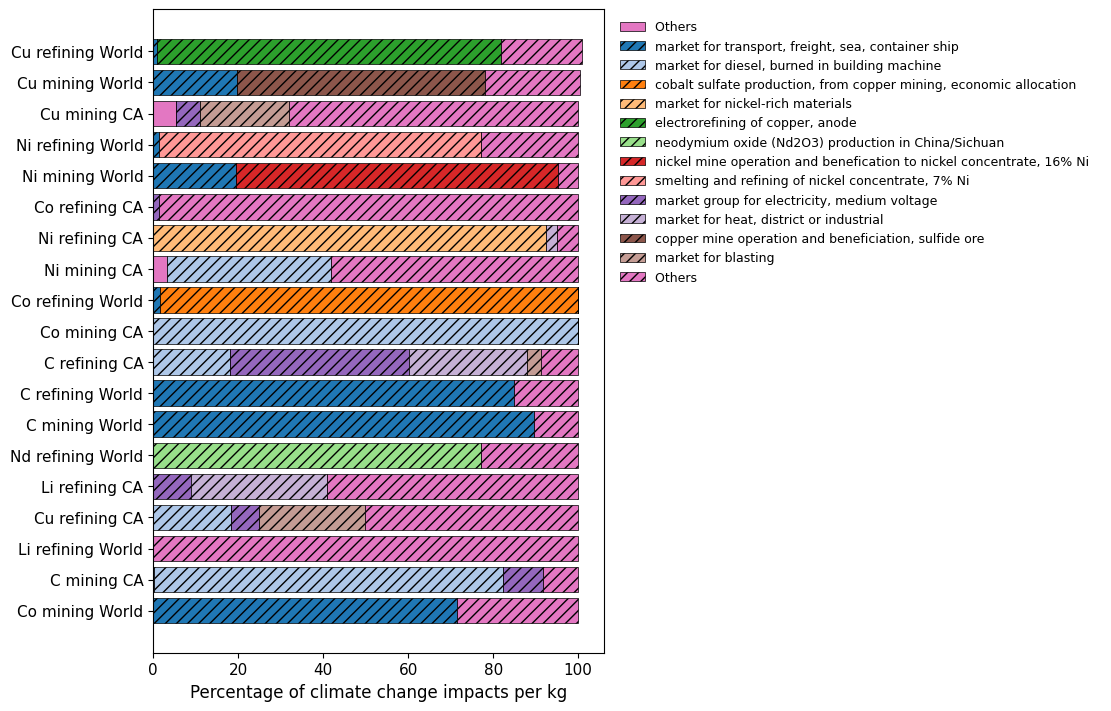

In [39]:
ca_gwp_ei = plot_stacked_contribution_by_activity(
    ca_ei_gwp,
    impact_col="share_%",
    commodity_col="lci_name",
    #merge_others_across_flow_types=True,     # <-- ONE Others
    xlabel="Percentage of climate change impacts per kg",
    output_path="results/LCA/contribution_analysis_gwp_ei.png",
)

# Prospective analysis

In [21]:
df_gwp

,Scenario,Year,Commodity,Geography,Metal,Reference point,Climate change ST (kg CO2 eq (short))
0,IMAGE_SSP2L,2020,C mining CA,Canada,Graphite,Mining,0.011673
1,IMAGE_SSP2L,2025,C mining CA,Canada,Graphite,Mining,0.011721
2,IMAGE_SSP2L,2030,C mining CA,Canada,Graphite,Mining,0.011305
3,IMAGE_SSP2L,2035,C mining CA,Canada,Graphite,Mining,0.010794
4,IMAGE_SSP2L,2040,C mining CA,Canada,Graphite,Mining,0.010267
...,...,...,...,...,...,...,...
90,IMAGE_SSP2L,2020,Ni refining World,World,Nickel,Mining+refining,15.603013
91,IMAGE_SSP2L,2025,Ni refining World,World,Nickel,Mining+refining,15.569435
92,IMAGE_SSP2L,2030,Ni refining World,World,Nickel,Mining+refining,15.395464
93,IMAGE_SSP2L,2035,Ni refining World,World,Nickel,Mining+refining,15.187742


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_gwp_base100_by_metal_refpoint(
    excel_path=None,
    df=None,
    sheet_name="GWP",
    impact_col="Climate change ST (kg CO2 eq (short))",
    base_year=2020,
    scenario=None,
    geography=None,
    metals=None,
    reference_points=None,
    title=None,
    figsize=(11, 6),
    dpi=300,
    output_path=None,
):
    """
    Trace l'évolution (base 100) d'un impact (ex: GWP) par année,
    avec couleur par métal et style de ligne par "Reference point".

    Paramètres
    ----------
    excel_path : str | None
        Chemin vers le fichier Excel (si df n'est pas fourni).
    df : pd.DataFrame | None
        DataFrame déjà chargé (si fourni, excel_path ignoré).
    sheet_name : str
        Nom de la feuille (par défaut "GWP").
    impact_col : str
        Nom exact de la colonne d'impact à tracer.
    base_year : int
        Année de référence (index 100).
    scenario : str | None
        Filtre sur une valeur exacte de la colonne "Scenario".
    geography : str | None
        Filtre sur une valeur exacte de la colonne "Geography".
    metals : list[str] | None
        Liste de métaux à inclure (sinon tous).
    reference_points : list[str] | None
        Liste de reference points à inclure (sinon tous).
    title : str | None
        Titre du graphique.
    figsize, dpi : paramètres Matplotlib.
    output_path : str | None
        Si renseigné, exporte la figure (png/pdf/svg, selon extension).
    """

    # ---------- Load ----------
    if df is None:
        if excel_path is None:
            raise ValueError("Fournis soit df, soit excel_path.")
        df = pd.read_excel(excel_path, sheet_name=sheet_name)

    required = {"Scenario", "Year", "Metal", "Reference point", impact_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Colonnes manquantes: {missing}")

    d = df.copy()

    # ---------- Filters ----------
    if scenario is not None:
        d = d[d["Scenario"] == scenario]
    if geography is not None and "Geography" in d.columns:
        d = d[d["Geography"] == geography]
    if metals is not None:
        d = d[d["Metal"].isin(metals)]
    if reference_points is not None:
        d = d[d["Reference point"].isin(reference_points)]

    # ---------- Clean + types ----------
    d = d.dropna(subset=["Year", "Metal", "Reference point", impact_col])
    d["Year"] = d["Year"].astype(int)

    # ---------- Base 100 computation ----------
    # Base par groupe (Metal, Reference point) + filtres déjà appliqués
    base = (
        d[d["Year"] == base_year]
        .groupby(["Metal", "Reference point"], as_index=False)[impact_col]
        .mean()
        .rename(columns={impact_col: "base_value"})
    )

    d = d.merge(base, on=["Metal", "Reference point"], how="left")
    d = d.dropna(subset=["base_value"])  # retire les groupes sans base_year

    d["Index (base 100)"] = (d[impact_col] / d["base_value"]) * 100.0

    # On agrège si plusieurs lignes par année (moyenne)
    plot_df = (
        d.groupby(["Year", "Metal", "Reference point"], as_index=False)["Index (base 100)"]
        .mean()
        .sort_values(["Metal", "Reference point", "Year"])
    )

    # ---------- Styling ----------
    metals_list = sorted(plot_df["Metal"].unique().tolist())
    ref_list = sorted(plot_df["Reference point"].unique().tolist())

    # couleurs automatiques Matplotlib (cycle)
    #color_map = {m: f"C{i % 10}" for i, m in enumerate(metals_list)}

    # ---------- Fixed color map by metal ----------
    fixed_color_map = {
        'Copper': '#8c510a',
        'Nickel': '#d8b365',
        'Graphite': '#f6e8c3',
        'Cobalt': '#c7eae5',
        'Lithium': '#5ab4ac',
        'Neodymium': '#01665e'
    }

    # Use fixed colors, fallback to matplotlib default if missing
    color_map = {
        m: fixed_color_map.get(m, f"C{i % 10}")
        for i, m in enumerate(metals_list)
    }

    # styles de lignes (étendable)
    linestyle_cycle = ["-", "--", ":", "-.", (0, (3, 1, 1, 1)), (0, (5, 2))]
    linestyle_map = {rp: linestyle_cycle[i % len(linestyle_cycle)] for i, rp in enumerate(ref_list)}

    # ---------- Plot ----------
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    for metal in metals_list:
        for rp in ref_list:
            sub = plot_df[(plot_df["Metal"] == metal) & (plot_df["Reference point"] == rp)]
            if sub.empty:
                continue
            ax.plot(
                sub["Year"],
                sub["Index (base 100)"],
                color=color_map[metal],
                linestyle=linestyle_map[rp],
                linewidth=2,
                alpha=0.95,
            )

    ax.axhline(100, linewidth=1)
    ax.set_xlabel("")
    ax.set_ylabel(f"Indice (base 100 = {base_year})")
    ax.set_title(title or f"Évolution de l'impact (base {base_year} = 100) – {impact_col}")
    ax.grid(True, which="both", axis="both", linewidth=0.5, alpha=0.3)

    # ---------- Dual legends ----------
# ---------- Legends (stacked bottom-left) ----------
    metal_handles = [
        Line2D([0], [0], color=color_map[m], lw=3, linestyle="-", label=m)
        for m in metals_list
    ]

    rp_handles = [
        Line2D([0], [0], color="black", lw=3, linestyle=linestyle_map[rp], label=rp)
        for rp in ref_list
    ]

    # First legend: metals (top)
    leg1 = ax.legend(
        handles=metal_handles,
        title="",
        loc="lower left",
        bbox_to_anchor=(0.01, 0.01),
        frameon=True,
    )

    # Second legend: reference points (just above)
    leg2 = ax.legend(
        handles=rp_handles,
        title="",
        loc="lower left",
        bbox_to_anchor=(0.01, 0.23),
        frameon=True,
    )

    ax.add_artist(leg1)


        # --- X axis: years as integers, every 5 years ---
    years = sorted(plot_df["Year"].unique())
    year_min, year_max = min(years), max(years)
    xticks = list(range(year_min, year_max + 1, 5))

    ax.set_xticks(xticks)
    ax.set_xticklabels([str(y) for y in xticks])


    fig.tight_layout()

    if output_path:
        fig.savefig(output_path, bbox_inches="tight")

    return fig, ax, plot_df


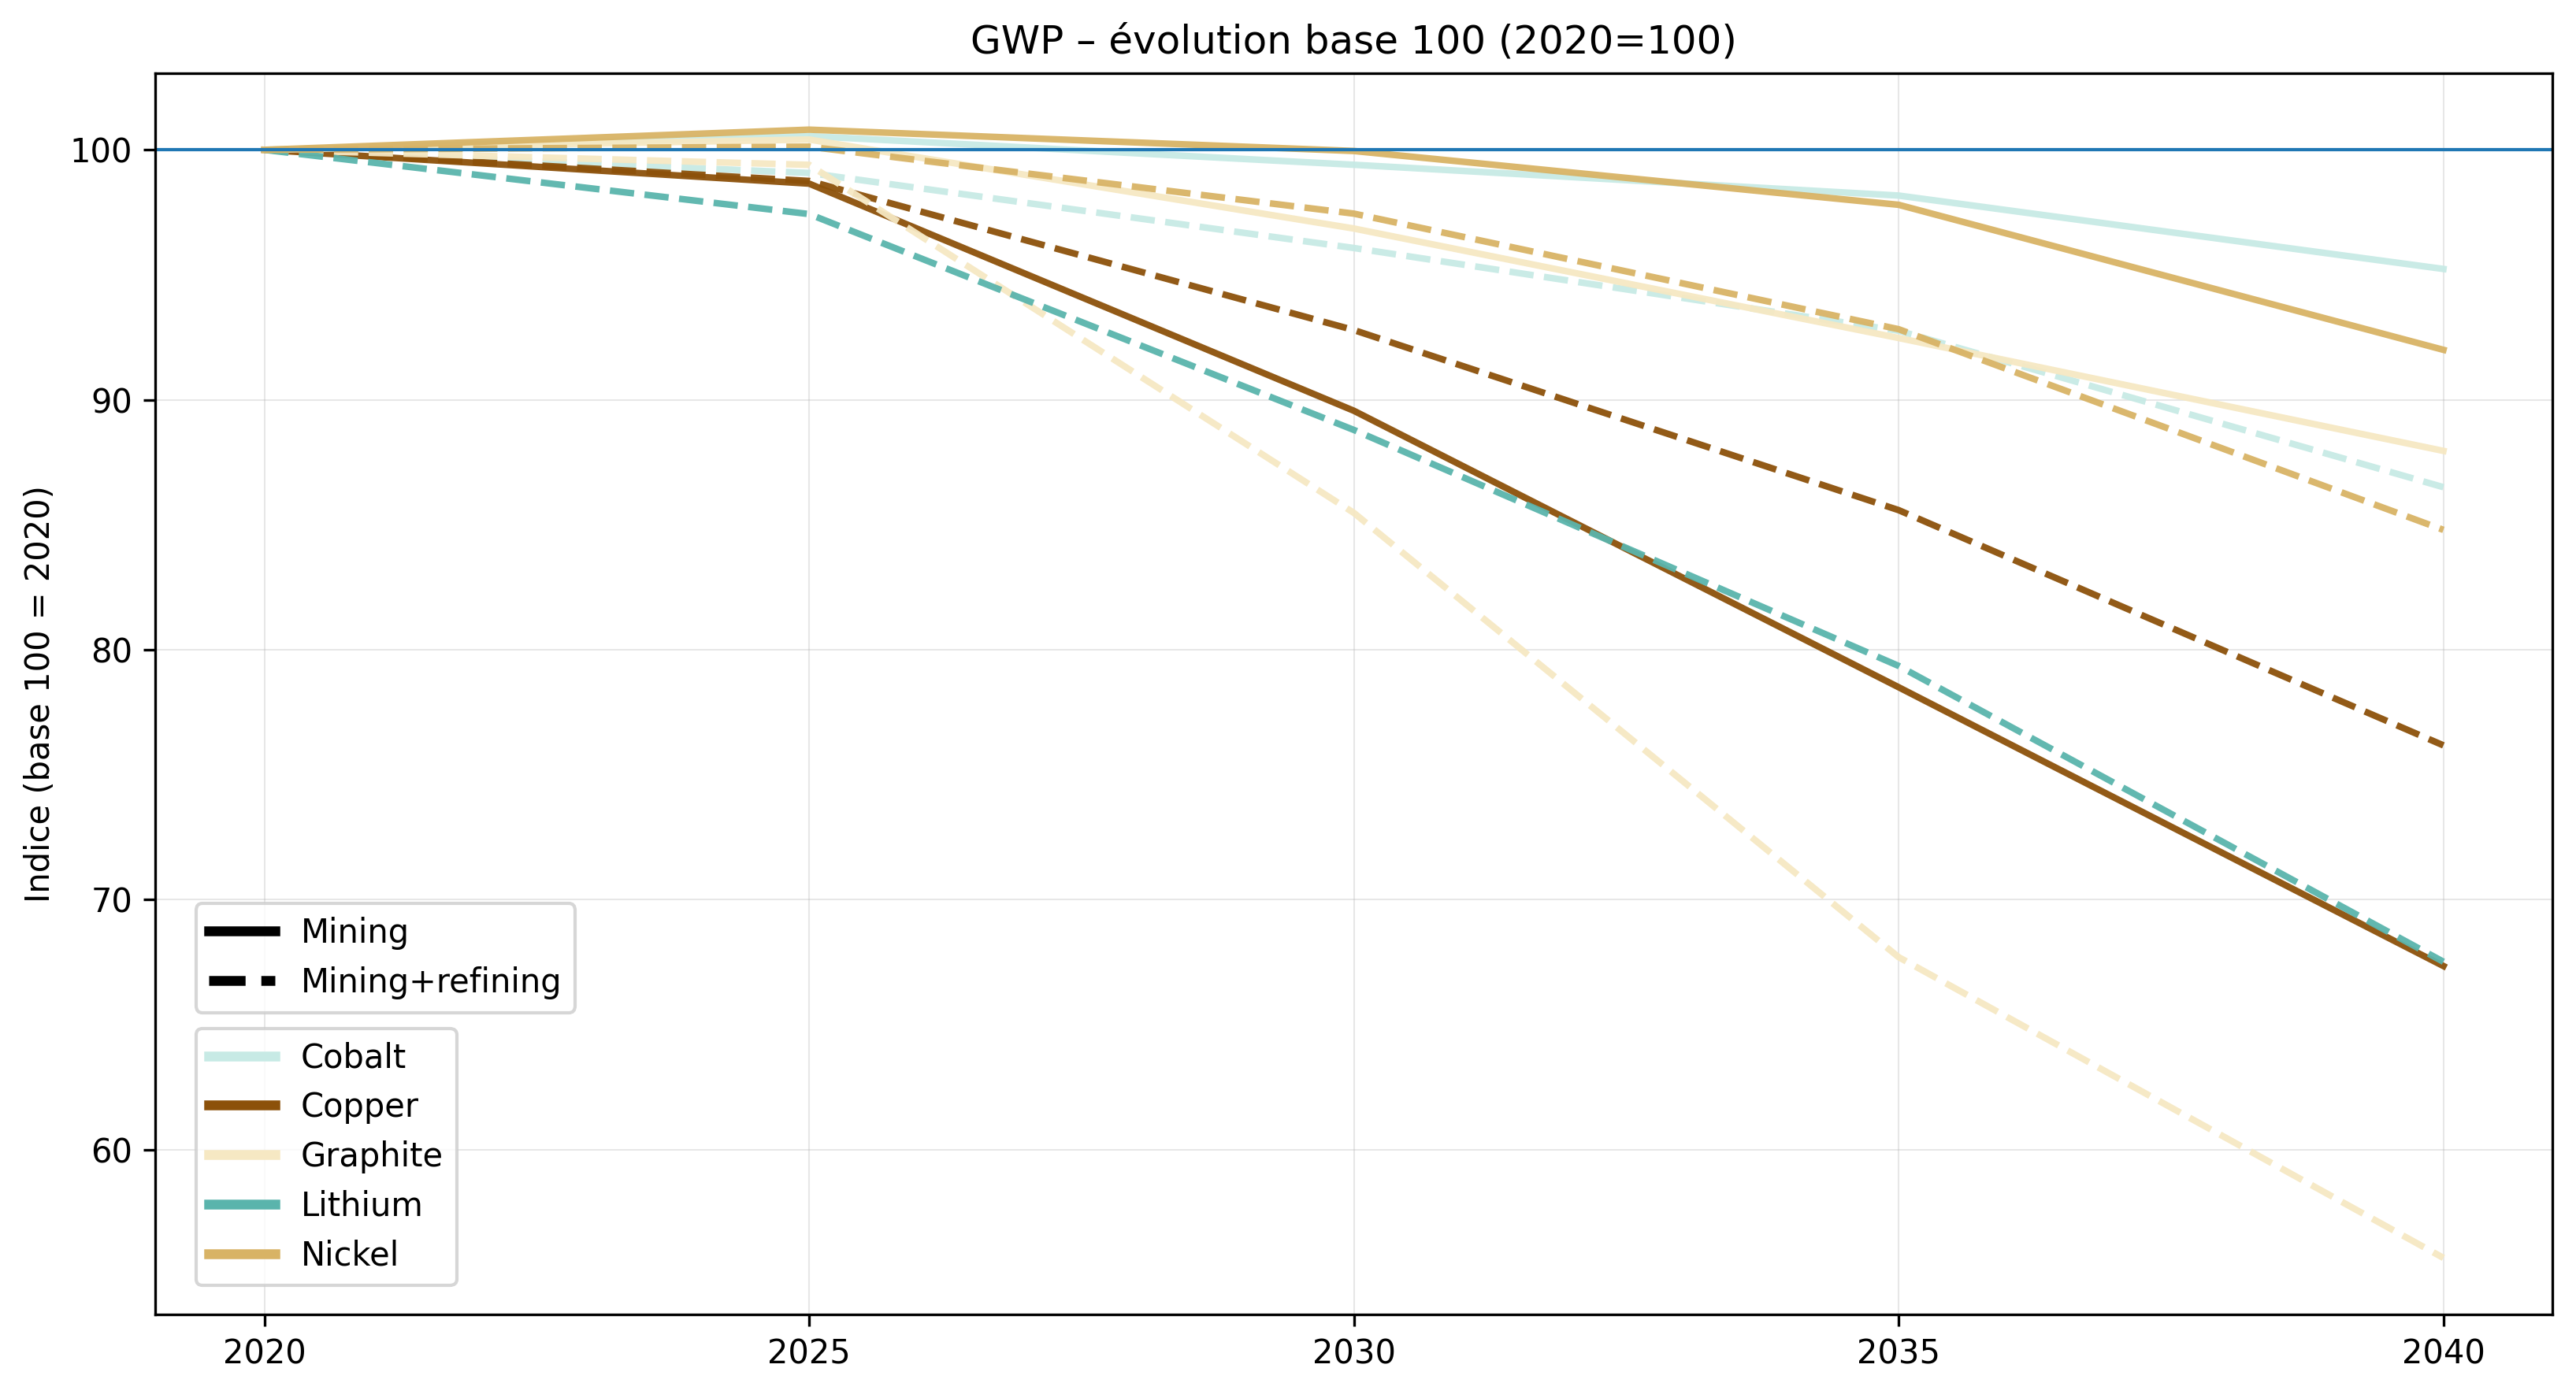

In [53]:
fig, ax, plot_df = plot_gwp_base100_by_metal_refpoint(
    excel_path="results/LCA/lcia_results_per_kg_per_scenarios.xlsx",
    sheet_name="GWP",
    impact_col="Climate change ST (kg CO2 eq (short))",
    base_year=2020,
    scenario="IMAGE_SSP2L",      # optionnel
    geography="Canada",          # optionnel
    title="GWP – évolution base 100 (2020=100)",
    output_path="results/LCA/gwp_base100.png"
)
plt.show()


# Extract production and demand data

In [ ]:
demand_df = pd.read_excel(r'data/data_lci.xlsx', sheet_name='DEMAND')
lci_demand = pd.read_excel(r'data/data_lci.xlsx', sheet_name='lci_demand')

In [ ]:
year = [2025, 2030, 2035, 2040]
demand_df = demand_df[demand_df['Year'].isin(year)]

In [ ]:
df_demand_agg = (demand_df
    .groupby(["Scenario", "Year", "Metal"])["Metal_demand_t"]
    .sum()
    .reset_index()
)


In [ ]:
df_demand_agg['Metal_demand_kg'] = df_demand_agg['Metal_demand_t'] * 1e3

In [ ]:
df_demand_cm = df_demand_agg[df_demand_agg['Scenario'] == 'Current Measures']
df_demand_nz = df_demand_agg[df_demand_agg['Scenario'] == 'Canada Net-zero']

In [ ]:
df_demand_agg

In [ ]:
lci_demand

In [ ]:
#lci_demand.to_csv(r'lci_demand.csv', index=False)
#df_demand_agg.to_csv(r'df_demand_agg.csv', index=False)

# LCA calculations

In [ ]:
from core.lca import setup_activities, run_scenario_lca

In [ ]:
lci_map = setup_activities(lci_demand)

In [ ]:
lci_map

In [ ]:
import numpy as np
import brightway2 as bw
import pandas as pd
from brightway2 import Database
from brightway2 import LCA
import numpy as np

def run_scenario_lca(df_demand_agg, activities_dict, lcia_methods):
    """
    Compute scaled LCA results for each row in df_demand_agg.
    df_demand_agg must contain:
        scenario, year, metal, metal_demand_kg
    """

    results = []

    for idx, row in df_demand_agg.iterrows():
        scenario = row["Scenario"]
        year = str(row["Year"])
        metal = row["Metal"]
        qty = float(row["Metal_demand_kg"])

        key = (scenario, year, metal)
        activity = activities_dict.get(key, None)

        impact_results = {}

        if activity is None:
            for m in lcia_methods:
                impact_results[m[2]] = np.nan

        else:
            try:
                lca = LCA({activity: qty}, lcia_methods[0])
                lca.lci()

                for method in lcia_methods:
                    lca.switch_method(method)
                    lca.lcia()
                    impact_results[method[2]] = lca.score

            except:
                for m in lcia_methods:
                    impact_results[m[2]] = np.nan

        results.append({
            "Scenario": scenario,
            "Year": year,
            "Metal": metal,
            "Demand_kg": qty,
            **impact_results
        })

    return pd.DataFrame(results)

In [ ]:
df_demand_lca = run_scenario_lca(df_demand_agg, lci_map, lcia_methods=IW_EP)

In [ ]:
df_demand_lca

In [ ]:
df_demand_lca.to_csv(r'results/LCA/df_demand_lca.csv', index=False)

In [ ]:
from utils.visualisations import plot_lca_stackplots_by_scenario
from utils.constants import selected_metal_colors

In [ ]:
fig_cm = plot_lca_stackplots_by_scenario(
    df_demand_lca,
    scenario="Current Measures",
    impact_cols=["Total human health", "Total ecosystem quality"],
    color_map=selected_metal_colors,
    group_small_metals=False,   # ← NO aggregation
    figsize=(11, 7),
    savepath="results/LCA/current_measures_ep"
)


In [ ]:
fig_nz = plot_lca_stackplots_by_scenario(
    df_demand_lca,
    scenario="Canada Net-zero",
    impact_cols=["Total human health", "Total ecosystem quality"],
    color_map=selected_metal_colors,
    group_small_metals=False,   # ← NO aggregation
    figsize=(11, 7),
    savepath="results/LCA/current_measures_nz"
)